## 📚 Literature Review References

To support our methodology and model architecture choices for the cloud masking task, we reviewed the following key references:

- 🔬 **Preprocessing, Augmentation & ResNet-34 U-Net**  
  [Preprocessing & Augmentation & ResNet-34 Pre-trained U-Net Architecture (OSTI.gov)](https://www.osti.gov/servlets/purl/1571370)  
  This paper discusses preprocessing and augmentation strategies for satellite image segmentation, and the use of ResNet-34 as a U-Net encoder for improved performance.

- 🌥️ **Cloud Type Categorization (Clouded, Partial, Cloud-Free)**  
  [Clouded, Partial, and Cloud-Free Classification with 11 Spectral Bands (MDPI)](https://www.mdpi.com/2072-4292/10/11/1782)  
  Offers insight into segmenting cloud coverage by classifying images as fully clouded, partially cloudy, or cloud-free using multi-band satellite inputs.

- 🧠 **U-Net Practical Guide**  
  [Segmentation of Clouds Using Deep Learning – U-Net (Medium)](https://medium.com/swlh/segmentation-of-clouds-in-satellite-images-using-deep-learning-a9f56e0aa83d)  
  A helpful walkthrough for implementing U-Net on satellite images, highlighting common challenges and practical tips.

- ⚙️ **ACLNet: Advanced Cloud Segmentation Architecture**  
  [ACLNet: Attention-Based Cloud Segmentation Network (arXiv)](https://arxiv.org/pdf/2207.06277)  
  Introduces a novel architecture with attention modules specifically designed for high-resolution cloud segmentation from satellite images.

- 🏛️ **VGG-16 as Encoder in U-Net**  
  [VGG-16-Based Cloud Segmentation Model (PLOS One)](https://pmc.ncbi.nlm.nih.gov/articles/PMC9901801/pdf/pone.0280408.pdf)  
  This study demonstrates the use of VGG-16 as a feature extractor in U-Net, providing an alternative to ResNet-based encoders for cloud detection.

In [18]:
!pip install tifffile


[notice] A new release of pip is available: 23.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip


In [19]:
from pathlib import Path
from PIL import Image
import tarfile
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import os
import matplotlib.pyplot as plt
import tifffile
from joblib import Parallel, delayed
import seaborn as sns
import cv2
import random
import gc
from tqdm import tqdm
import albumentations as A
import uuid

In [20]:
!ls /kaggle/input/cloud-masking-dataset/content/train

data  masks


In [21]:
DATASET_DIR = Path("/kaggle/input/cloud-masking-dataset/content/train")
IMGS_DIR =   DATASET_DIR / "data"
MASKS_DIR =   DATASET_DIR / "masks"

img_names = sorted([img_path.stem for img_path in IMGS_DIR.glob("*.tif")])
print(f"Total images found: {len(img_names)}")

Total images found: 10573


## 📊 Exploratory Data Analysis (EDA)

We began our data exploration by validating the dataset structure:

- ✅ **Mask Existence Check**: We looped through all image files in the dataset to ensure that each image has a corresponding mask with a matching filename.
- ✅ **Dimension Consistency**: We confirmed that each image and its corresponding mask share the same dimensions, which is crucial for pixel-wise segmentation.

Once validation was complete, we visualized several training samples by overlaying masks on top of their images. This helped us **identify a critical issue**:

- ⚠️ **Incorrect Masks Detected**: Some images had mismatched or incorrect masks (e.g., masks covering irrelevant regions or having misaligned boundaries).  
  ➤ This problem will be addressed during the **preprocessing phase**, where we plan to implement validation filters or correction heuristics.

We then analyzed the dataset distribution by classifying images into three categories:
- **Fully Clouded**
- **Partially Clouded**
- **Cloud-Free**

📊 **Observation**: The distribution is **imbalanced**, with a heavier bias toward **partially clouded** images.  
➤ This imbalance may affect model generalization, so we will account for it using appropriate **data augmentation and sampling strategies** during preprocessing.

### Dataset Validation

In [22]:
# Process a single image-mask pair
def process_file(img_id, imgs_dir, masks_dir):
    img_path = imgs_dir / f"{img_id}.tif"
    mask_path = masks_dir / f"{img_id}.tif"
    result = {'img_id': img_id, 'missing_mask': False, 'dimension_mismatch': None}

    # Check if mask exists
    if not mask_path.exists():
        result['missing_mask'] = True
        return result

    try:
        # Use TiffFile to check dimensions without loading full image
        with tifffile.TiffFile(img_path) as img_tif, tifffile.TiffFile(mask_path) as mask_tif:
            img_shape = img_tif.pages[0].shape
            mask_shape = mask_tif.pages[0].shape

            # Check dimension consistency (height and width only)
            if img_shape[:2] != mask_shape[:2]:
                result['dimension_mismatch'] = (img_shape, mask_shape)

    except Exception as e:
        print(f"Error processing {img_id}: {e}")

    return result

# Parallel processing of files (n_jobs=-1 uses all available CPU cores)
results = Parallel(n_jobs=-1, verbose=1)(
    delayed(process_file)(img_id, IMGS_DIR, MASKS_DIR) for img_id in img_names
)

# Aggregate results
missing_masks = [r['img_id'] for r in results if r['missing_mask']]
dimension_mismatches = [(r['img_id'], r['dimension_mismatch'][0], r['dimension_mismatch'][1])
                       for r in results if r['dimension_mismatch'] is not None]

# Print validation results
total_images = len(img_names)
print(f"Missing masks: {len(missing_masks)} ({len(missing_masks)/total_images*100:.2f}%)")
if missing_masks:
    print("Files with missing masks:", missing_masks)

print(f"Dimension mismatches: {len(dimension_mismatches)} ({len(dimension_mismatches)/total_images*100:.2f}%)")
if dimension_mismatches:
    for img_id, img_shape, mask_shape in dimension_mismatches:
        print(f"Mismatch - {img_id}: Image shape {img_shape}, Mask shape {mask_shape}")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 96 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 out of   1 | elapsed:   23.6s finished
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   23.9s
[Parallel(n_jobs=-1)]: Done 259 tasks      | elapsed:   24.3s
[Parallel(n_jobs=-1)]: Done 609 tasks      | elapsed:   24.8s
[Parallel(n_jobs=-1)]: Done 1059 tasks      | elapsed:   25.4s
[Parallel(n_jobs=-1)]: Done 1609 tasks      | elapsed:   26.1s
[Parallel(n_jobs=-1)]: Done 2259 tasks      | elapsed:   27.0s
[Parallel(n_jobs=-1)]: Done 3009 tasks      | elapsed:   28.0s
[Parallel(n_jobs=-1)]: Done 3859 tasks      | elapsed:   29.2s
[Parallel(n_jobs=-1)]: Done 4809 tasks      | elapsed:   30.6s
[Parallel(n_jobs=-1)]: Done 5859 tasks      | elapsed:   32.1s
[Parallel(n_jobs=-1)]: Done 7009 tasks      | elapsed:   33.8s
[Parallel(n_jobs=-1)]: Done 8259 tasks      | elapsed:   35.6s
[Parallel(n_jobs=-1)]: Done 9609 tasks      | elapsed:   37.5s
[Parallel(n_jobs=-1)]: Done 10573 ou

Missing masks: 0 (0.00%)
Dimension mismatches: 0 (0.00%)


### Visualize Samples and Potential Mislabels

Visualizing random samples to understand the dataset:


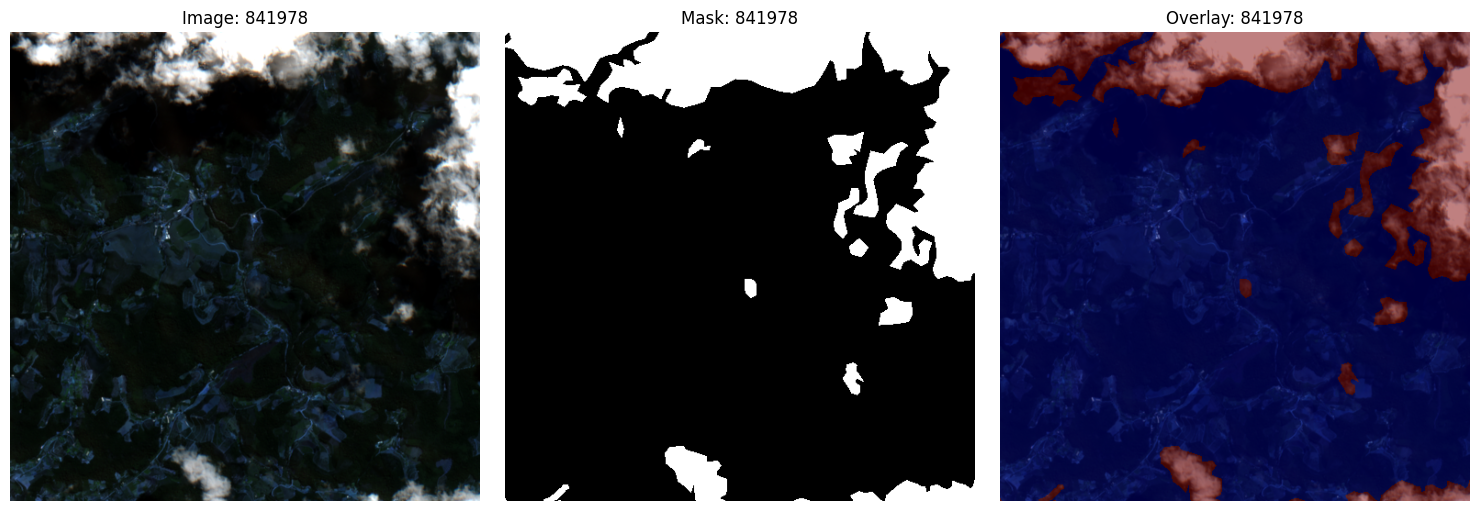

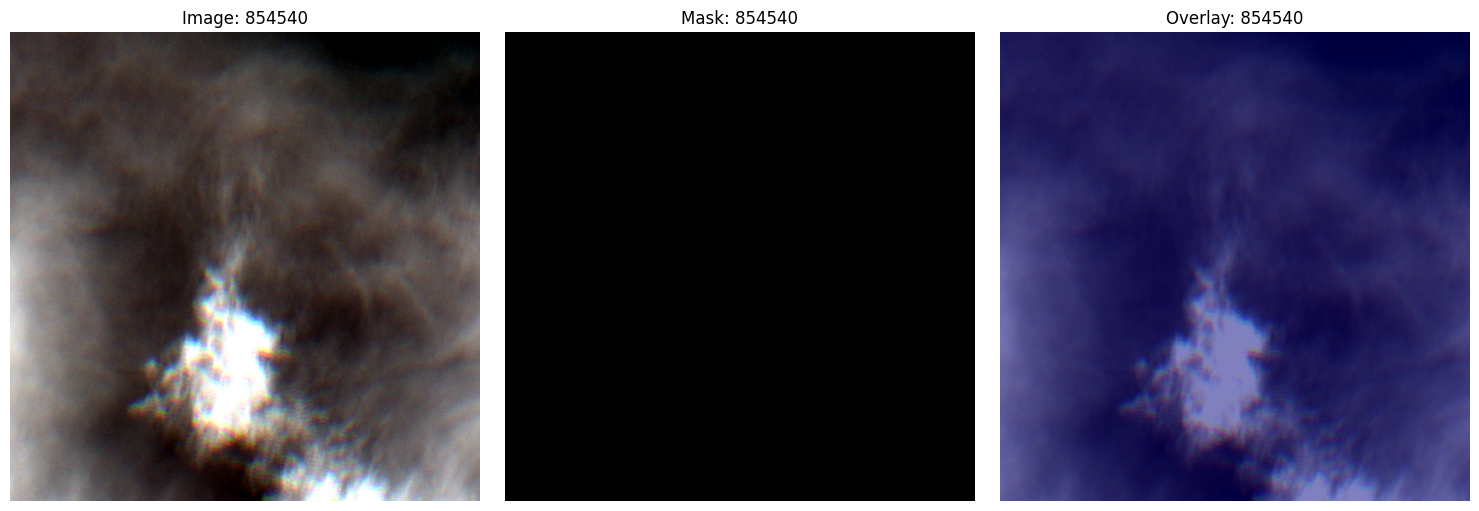

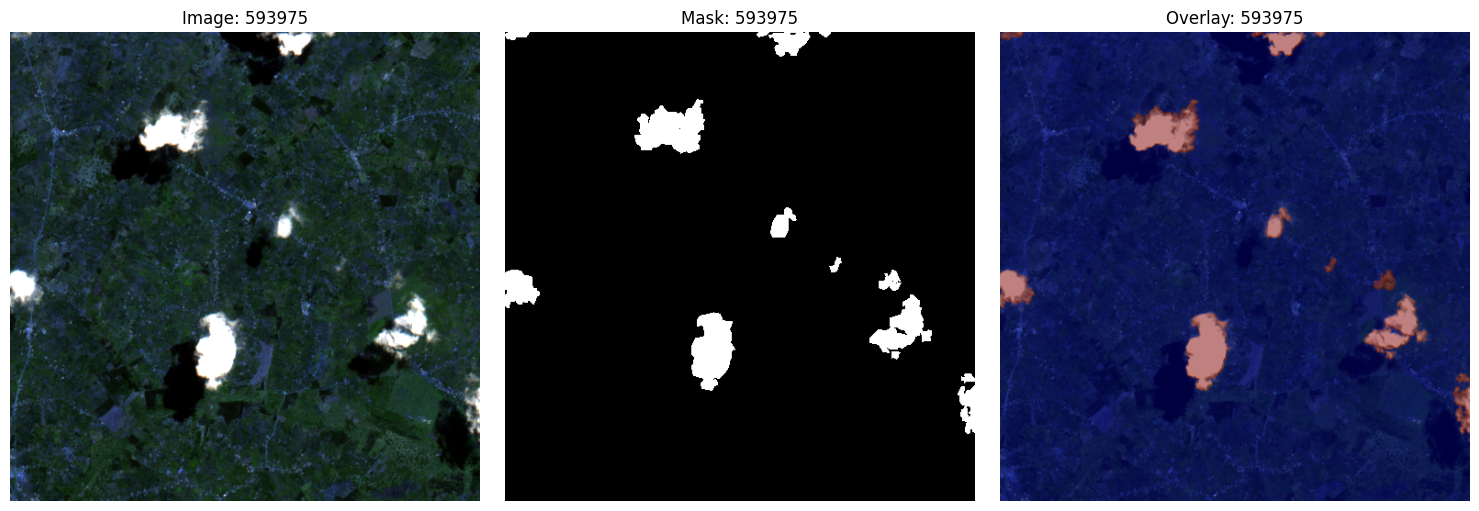

In [23]:
def normalize_img(img, lower_percent=2, upper_percent=98):
    out = np.zeros_like(img, dtype=np.float32)
    for i in range(3):
        band = img[:, :, i]
        min_val = np.percentile(band, lower_percent)
        max_val = np.percentile(band, upper_percent)
        out[:, :, i] = np.clip((band - min_val) / (max_val - min_val + 1e-6), 0, 1)
    return out

def visualize_samples(num_samples=3):
    print("Visualizing random samples to understand the dataset:")
    sample_names = random.sample(img_names, min(num_samples, len(img_names)))
    
    for name in sample_names:
        img_path = IMGS_DIR / f"{name}.tif"
        mask_path = MASKS_DIR / f"{name}.tif"

        if img_path.exists() and mask_path.exists():
            img = tifffile.imread(img_path)
            mask = tifffile.imread(mask_path)

            rgb_img = img[:, :, :3]  # R, G, B for visualization
            norm_rgb = normalize_img(rgb_img)

            fig, axs = plt.subplots(1, 3, figsize=(15, 5))
            axs[0].imshow(norm_rgb)
            axs[0].set_title(f"Image: {name}")
            axs[0].axis('off')

            axs[1].imshow(mask, cmap='gray')
            axs[1].set_title(f"Mask: {name}")
            axs[1].axis('off')

            # Overlay mask on image to spot misalignment
            axs[2].imshow(norm_rgb)
            axs[2].imshow(mask, alpha=0.5, cmap='jet')
            axs[2].set_title(f"Overlay: {name}")
            axs[2].axis('off')

            plt.tight_layout()
            plt.show()
        else:
            print(f"Missing image or mask for {name}")

visualize_samples(num_samples=3)

### Calculate Cloud Coverage

In [24]:
def calculate_cloud_coverage(mask_path):
    try:
        mask = tifffile.imread(mask_path)
        total_pixels = mask.size
        cloud_pixels = np.count_nonzero(mask)
        return (cloud_pixels / total_pixels) * 100
    except Exception as e:
        print(f"Error calculating coverage for {mask_path}: {e}")
        return None

coverage_data = []
for name in img_names:
    mask_path = MASKS_DIR / f"{name}.tif"
    if mask_path.exists():
        coverage = calculate_cloud_coverage(mask_path)
        if coverage is not None:
            coverage_data.append({'image_name': name, 'cloud_coverage': coverage})

coverage_df = pd.DataFrame(coverage_data)
print(f"Coverage calculated for {len(coverage_df)} images")

Coverage calculated for 10573 images


### Categorize Cloud Coverage

In [25]:
def categorize_coverage(coverage):
    if coverage < 10:
        return 'Cloud-Free'
    elif coverage > 90:
        return 'Fully Clouded'
    else:
        return 'Partially Cloudy'

coverage_df['category'] = coverage_df['cloud_coverage'].apply(categorize_coverage)
print(coverage_df['category'].value_counts())

category
Partially Cloudy    4634
Fully Clouded       4316
Cloud-Free          1623
Name: count, dtype: int64


### Visualize Distribution

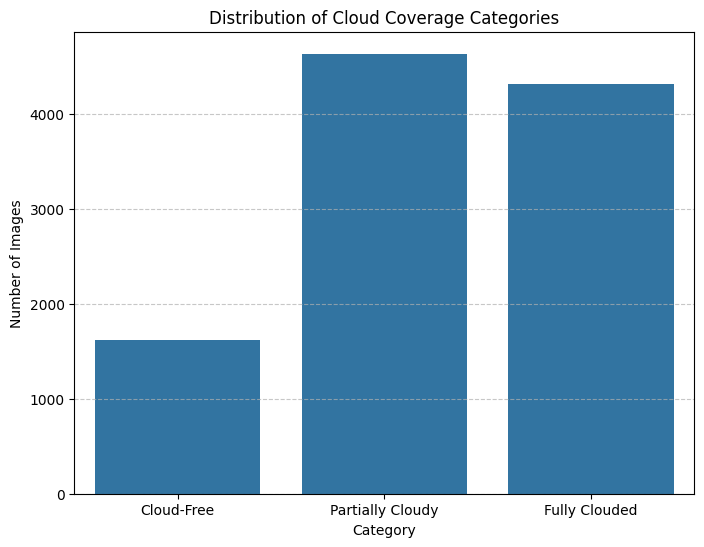

In [26]:
plt.figure(figsize=(8, 6))
sns.countplot(data=coverage_df, x='category', order=['Cloud-Free', 'Partially Cloudy', 'Fully Clouded'])
plt.title('Distribution of Cloud Coverage Categories')
plt.xlabel('Category')
plt.ylabel('Number of Images')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 🧹 Preprocessing

This phase focused on addressing the key issues identified during EDA and preparing the dataset for efficient and effective model training.

### 🛠️ Addressing EDA-Detected Issues

- **Incorrect Mask Alignment**:  
  We implemented validation checks to ensure that each image has a correctly aligned mask. Any sample with a mismatched or corrupt mask was excluded from the training set to prevent misleading the model during learning.

- **Class Imbalance**:  
  Given the overrepresentation of **partially clouded** images, we applied **targeted data augmentation** to underrepresented classes (fully clouded and cloud-free) to balance the training distribution and improve generalization.

---

### 🎨 Data Augmentation

To improve the robustness of our model, we applied the following augmentations to both images and their corresponding masks:

- **Random Rotations**
- **Random Translations**
- **Horizontal and Vertical Flips**

These techniques help the model generalize better by simulating different viewing angles and spatial arrangements often encountered in satellite imagery.

---

### 🌈 Band Selection

We chose to use **all four spectral bands** available in the dataset:

- **Red, Green, Blue**: Capture standard visual information.
- **Infrared (NIR)**: Enhances the model's ability to distinguish cloud cover due to its sensitivity to moisture and heat signatures.

Using all four bands provides the model with a richer feature space for more accurate cloud detection.

---

### 📏 Image Normalization

We normalized all input images by **scaling pixel values to the range [0, 1]**.  
This step ensures more stable and efficient training, allowing the model to converge faster and avoid issues caused by varying pixel intensity ranges across bands.

### Define Augmentation Pipeline for random rotations, translations, and flips

In [27]:
import albumentations as A

In [28]:
# Define augmentation pipeline
augmentation_pipeline = A.Compose([
    A.Rotate(limit=360, p=0.5),  # Random rotation 0-360 degrees
    A.Affine(translate_percent=0.1, scale=1.0, rotate=0, shear=0, p=0.5),  # Random translation (±10%)
    A.HorizontalFlip(p=0.5),  # Horizontal flip
    A.VerticalFlip(p=0.5),  # Vertical flip
], additional_targets={'mask': 'mask'})

print("Augmentation pipeline defined with rotations, translations, and flips.")

Augmentation pipeline defined with rotations, translations, and flips.


### Load and Categorize Images

In [29]:
# Create ID lists per category from your coverage DataFrame
cloud_free_ids = coverage_df.loc[coverage_df['category'] == 'Cloud-Free', 'image_name'].tolist()
fully_clouded_ids = coverage_df.loc[coverage_df['category'] == 'Fully Clouded', 'image_name'].tolist()
partially_clouded_ids = coverage_df.loc[coverage_df['category'] == 'Partially Cloudy', 'image_name'].tolist()

# Summary
print(f"Found {len(cloud_free_ids)} Cloud-Free images.")
print(f"Found {len(fully_clouded_ids)} Fully Clouded images.")
print(f"Found {len(partially_clouded_ids)} Partially Cloudy images.")

Found 1623 Cloud-Free images.
Found 4316 Fully Clouded images.
Found 4634 Partially Cloudy images.


### Apply Augmentation

In [33]:
# Fallback for writable path if needed (e.g., in Kaggle)
AUG_IMGS_DIR = Path("/kaggle/working/aug_data")
AUG_MASKS_DIR = Path("/kaggle/working/aug_masks")
AUG_IMGS_DIR.mkdir(parents=True, exist_ok=True)
AUG_MASKS_DIR.mkdir(parents=True, exist_ok=True)

# Augmentation function
def augment_and_save(images_to_augment, target_size, prefix):
    new_ids = []
    pbar = tqdm(total=target_size - len(images_to_augment), desc=f"Augmenting {prefix}")
    
    while len(new_ids) < (target_size - len(images_to_augment)):
        img_id = random.choice(images_to_augment)
        img_path = IMGS_DIR / f"{img_id}.tif"
        mask_path = MASKS_DIR / f"{img_id}.tif"

        if not img_path.exists() or not mask_path.exists():
            continue

        image = tifffile.imread(img_path)
        mask = tifffile.imread(mask_path)

        augmented = augmentation_pipeline(image=image, mask=mask)
        aug_img = augmented['image']
        aug_mask = augmented['mask']

        new_id = f"{prefix}_aug_{uuid.uuid4().hex[:8]}"
        new_img_path = AUG_IMGS_DIR / f"{new_id}.tif"
        new_mask_path = AUG_MASKS_DIR / f"{new_id}.tif"

        tifffile.imwrite(new_img_path, aug_img)
        tifffile.imwrite(new_mask_path, aug_mask)

        new_ids.append(new_id)
        pbar.update(1)
    
    pbar.close()
    return new_ids

# Target for each category
target_count = 5000

# Apply augmentation and get new IDs
cloud_free_new_ids = augment_and_save(cloud_free_ids, target_count, 'cloudfree')
fully_clouded_new_ids = augment_and_save(fully_clouded_ids, target_count, 'clouded')
partially_clouded_new_ids = augment_and_save(partially_clouded_ids, target_count, 'partclouded')

# Update ID lists
cloud_free_ids += cloud_free_new_ids
fully_clouded_ids += fully_clouded_new_ids
partially_clouded_ids += partially_clouded_new_ids

print(f"Final Cloud-Free Count: {len(cloud_free_ids)}")
print(f"Final Fully Clouded Count: {len(fully_clouded_ids)}")
print(f"Final Partially Cloudy Count: {len(partially_clouded_ids)}")



Augmenting cloudfree:   0%|          | 0/3377 [00:00<?, ?it/s]

Augmenting cloudfree:   0%|          | 7/3377 [00:00<00:50, 67.10it/s]

Augmenting cloudfree:   0%|          | 15/3377 [00:00<00:45, 73.69it/s]

Augmenting cloudfree:   1%|          | 25/3377 [00:00<00:40, 83.51it/s]

Augmenting cloudfree:   1%|          | 34/3377 [00:00<00:40, 81.69it/s]

Augmenting cloudfree:   1%|▏         | 43/3377 [00:00<00:46, 72.47it/s]

Augmenting cloudfree:   2%|▏         | 52/3377 [00:00<00:46, 72.26it/s]

Augmenting cloudfree:   2%|▏         | 62/3377 [00:00<00:41, 79.17it/s]

Augmenting cloudfree:   2%|▏         | 71/3377 [00:00<00:40, 80.81it/s]

Augmenting cloudfree:   2%|▏         | 81/3377 [00:01<00:38, 86.02it/s]

Augmenting cloudfree:   3%|▎         | 90/3377 [00:01<00:39, 84.03it/s]

Augmenting cloudfree:   3%|▎         | 99/3377 [00:01<00:38, 84.47it/s]

Augmenting cloudfree:   3%|▎         | 108/3377 [00:01<00:38, 85.85it/s]

Augmenting cloudfree:   3%|▎         | 117/3377 [00:01<00:

Final Cloud-Free Count: 5000
Final Fully Clouded Count: 5000
Final Partially Cloudy Count: 5000


## 🧠 Model Training

To explore both traditional and modern approaches to image segmentation

---

### 🧠 Deep Learning Approach: U-Net with variants

For our deep learning solution, we implemented the **U-Net** architecture — a widely used convolutional neural network for biomedical and satellite image segmentation tasks.

- **Architecture Highlights**:  
  - Encoder-Decoder structure  
  - Skip connections for preserving spatial features  
  - Ability to handle pixel-level predictions effectively  

We trained U-Net on 512×512 images using all four spectral bands as input channels. The model outputs a binary segmentation mask, which we threshold to create a clean cloud mask.

🔥 **Why U-Net?**  
- Specifically designed for semantic segmentation.  
- Performs well even with limited training data due to its efficient use of spatial features.  
- Flexible and extensible: allows the use of pre-trained encoders (e.g., ResNet, VGG).  
- Proven effectiveness in related satellite image tasks based on our literature review.

---

We evaluated using the **Dice Coefficient**, which is well-suited for segmentation problems and aligns with the competition requirements.


### Model training using pytorch 

In [34]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AttentionGate(nn.Module):
    """Attention Gate block for skip connections in Attention U-Net"""
    def __init__(self, F_g, F_l, F_int):
        super(AttentionGate, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class DoubleConv(nn.Module):
    """(Conv -> BN -> LeakyReLU) × 3 with residual connection"""
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            # First conv block
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(inplace=True),
            
            # Second conv block
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(inplace=True),
            
            # Third conv block
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(inplace=True)
        )
        
        # Residual connection if input and output channels differ
        self.residual = nn.Sequential()
        if in_channels != out_channels:
            self.residual = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels)
            )
            
    def forward(self, x):
        residual = self.residual(x)
        return self.conv(x) + residual

class AttentionUNet(nn.Module):
    def __init__(self, in_channels=4, out_channels=1, features=[32, 64, 128, 256], use_attention=True):
        super(AttentionUNet, self).__init__()
        self.use_attention = use_attention
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
        
        # Downsampling path
        in_channels_temp = in_channels
        for feature in features:
            self.downs.append(DoubleConv(in_channels_temp, feature))
            in_channels_temp = feature
            
        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1]*2)
        
        # Upsampling path
        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2)
            )
            self.ups.append(DoubleConv(feature*2, feature))
            
        # Final convolution
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)
        
        # Attention gates created dynamically during forward pass
        if self.use_attention:
            self.attention_gates = nn.ModuleDict()
            
    def forward(self, x):
        skip_connections = []
        
        # Downsampling path and collect skip connections
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)
            
        x = self.bottleneck(x)
        
        # Reverse skip connections for upsampling path
        skip_connections = skip_connections[::-1]
        
        # Upsampling path
        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)  # Upsample
            skip_connection = skip_connections[idx//2]
            
            # Create attention gate dynamically with correct dimensions if needed
            if self.use_attention:
                # Get actual channel dimensions
                F_g = x.size(1)  # Channels from upsampling path
                F_l = skip_connection.size(1)  # Channels from skip connection
                F_int = min(F_g, F_l) // 2  # Intermediate channels
                
                gate_key = f"gate_{idx//2}"
                if gate_key not in self.attention_gates:
                    self.attention_gates[gate_key] = AttentionGate(F_g, F_l, F_int).to(x.device)
                
                # Apply attention gate
                skip_connection = self.attention_gates[gate_key](x, skip_connection)
                
            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx+1](concat_skip)  # DoubleConv
            
        return self.final_conv(x)
# Instantiate the model
def get_model(use_attention=True):
    return AttentionUNet(in_channels=4, out_channels=1, use_attention=use_attention)

## Satellite Dataset Preparation and DataLoader

This section defines the `SatelliteDataset` class and utility functions for preparing data loaders for satellite image segmentation tasks.

- **SatelliteDataset**:  
  A custom PyTorch `Dataset` for loading satellite images and their corresponding masks.  
  - Handles both original and augmented images.
  - Loads `.tif` images and masks, normalizes images to `[0, 1]`, and binarizes masks.
  - Applies optional transformations (e.g., resizing).
  - Returns tensors in the format required by PyTorch models.

- **get_transforms(phase)**:  
  Returns an Albumentations transformation pipeline for the given phase (`train` or `valid`).  
  Currently, only resizing is applied, as augmentations are assumed to be handled during preprocessing.

- **prepare_loaders(image_ids, train_split=0.8, batch_size=16)**:  
  Splits the dataset into training and validation sets, creates corresponding `SatelliteDataset` instances, and returns PyTorch `DataLoader` objects for efficient batch loading.

**Usage Example:**
```python
train_loader, val_loader = prepare_loaders(image_ids, train_split=0.8, batch_size=16)
```

In [35]:
class SatelliteDataset(Dataset):
    def __init__(self, image_ids, imgs_dir, masks_dir, transform=None):
        self.image_ids = image_ids
        self.imgs_dir = imgs_dir
        self.masks_dir = masks_dir
        self.transform = transform
        
    def __len__(self):
        return len(self.image_ids)
    
    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        
        # Choose correct directory based on if it's original or augmented
        if img_id.startswith(('cloudfree', 'clouded', 'partclouded')):
            img_path = AUG_IMGS_DIR / f"{img_id}.tif"
            mask_path = AUG_MASKS_DIR / f"{img_id}.tif"
        else:
            img_path = IMGS_DIR / f"{img_id}.tif"
            mask_path = MASKS_DIR / f"{img_id}.tif"
        
        # Load image and mask
        image = tifffile.imread(img_path)  # Shape: (H, W, C) with C=4
        mask = tifffile.imread(mask_path)  # Shape: (H, W)
        
        # Apply transformations if any
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        
        # Normalize image values to [0, 1]
        image = image.astype(np.float32) / 255.0
        
        # Convert mask to binary (0 or 1)
        mask = (mask > 0).astype(np.float32)
        
        # Move channel dimension to first position for PyTorch (C, H, W)
        image = np.transpose(image, (2, 0, 1))
        mask = np.expand_dims(mask, 0)  # Add channel dimension (1, H, W)
        
        return torch.from_numpy(image), torch.from_numpy(mask)

# Define transforms
def get_transforms(phase):
    if phase == 'train':
        return A.Compose([
            A.Resize(512, 512),  # Resize to model input size
            # No additional augmentations here as they were applied during preprocessing
        ])
    else:
        return A.Compose([
            A.Resize(512, 512),  # Resize to model input size
        ])

def prepare_loaders(image_ids, train_split=0.8, batch_size=16):
    # Split data into train and validation
    train_size = int(len(image_ids) * train_split)
    train_ids = image_ids[:train_size]
    val_ids = image_ids[train_size:]
    
    # Create datasets
    train_dataset = SatelliteDataset(
        train_ids, 
        imgs_dir=IMGS_DIR, 
        masks_dir=MASKS_DIR,
        transform=get_transforms('train')
    )
    
    val_dataset = SatelliteDataset(
        val_ids, 
        imgs_dir=IMGS_DIR, 
        masks_dir=MASKS_DIR,
        transform=get_transforms('valid')
    )
    
    # Create data loaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4,
        pin_memory=True,
        drop_last=True
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        drop_last=False
    )
    
    return train_loader, val_loader

## Loss Functions and Model Training

This section defines the loss functions and the training loop for the satellite image segmentation model.

- **dice_loss(pred, target, smooth=1.)**:  
  Computes the Dice loss, which measures overlap between predicted and ground truth masks. Useful for segmentation tasks with imbalanced classes.

- **calc_loss(pred, target, metrics, bce_weight=0.5)**:  
  Combines Binary Cross Entropy (BCE) loss and Dice loss for a balanced segmentation loss.  
  - `bce_weight` controls the contribution of BCE vs. Dice loss.
  - Updates a metrics dictionary for tracking loss components.

- **train_model(model, train_loader, val_loader, device, num_epochs=10)**:  
  Trains the model using mixed precision (with `autocast` and `GradScaler` for efficiency on CUDA devices).  
  - Performs training and validation for each epoch.
  - Prints average training and validation loss per epoch.
  - Uses Adam optimizer and supports gradient scaling for stability.

**Usage Example:**
```python
trained_model = train_model(model, train_loader, val_loader, device='cuda', num_epochs=10)
```

In [36]:

from torch.cuda.amp import autocast, GradScaler


def dice_loss(pred, target, smooth=1.):
    pred = pred.contiguous()
    target = target.contiguous()

    intersection = (pred * target).sum(dim=2).sum(dim=2)

    loss = (1 - ((2. * intersection + smooth) / (pred.sum(dim=2).sum(dim=2) + target.sum(dim=2).sum(dim=2) + smooth)))

    return loss.mean()


def calc_loss(pred, target,metrics, bce_weight=0.5):
    bce = F.binary_cross_entropy_with_logits(pred, target)

    pred = F.sigmoid(pred)
    dice = dice_loss(pred, target)

    loss = bce * bce_weight + dice * (1 - bce_weight)

    metrics['bce'] += bce.data.cpu().numpy() * target.size(0)
    metrics['dice'] += dice.data.cpu().numpy() * target.size(0)
    metrics['loss'] += loss.data.cpu().numpy() * target.size(0)

    return loss

def train_model(model, train_loader, val_loader, device, num_epochs=10):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    scaler = torch.amp.GradScaler('cuda')
    model = model.to(device)
    
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            images = images.to(device)
            masks = masks.to(device)
            
            optimizer.zero_grad()
            with autocast():
                outputs = model(images)
                # loss = mae_loss(outputs, masks)
                loss = calc_loss(outputs, masks)
                
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            train_loss += loss.item()
        
        # Validation (simplified, can also use autocast)
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks = masks.to(device)
                outputs = model(images)
                loss = calc_loss(outputs, masks)
                val_loss += loss.item()
        
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss/len(train_loader):.4f}, Val Loss: {val_loss/len(val_loader):.4f}")
        torch.cuda.empty_cache()
        gc.collect()
    
    return model

In [ ]:
# torch.cuda.empty_cache()
# gc.collect()
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# all_ids = cloud_free_ids + fully_clouded_ids + partially_clouded_ids
# print(len(all_ids[:5000]))

# train_loader, val_loader = prepare_loaders(all_ids[:4000], train_split=0.8, batch_size=8)

# model = AttentionUNet(in_channels=4, out_channels=1, 
#                       features=[64, 128, 256, 512], 
#                       use_attention=True)
# trained_model = train_model(model, train_loader, val_loader, device, num_epochs=5)
# torch.save(trained_model.state_dict(), 'attention_unet_model.pth')

## 📈 Model Train with SM library and TPU

## TensorFlow TPU/CPU/GPU Setup

This section initializes the TensorFlow distributed strategy for training:

- **TPU Initialization**:  
  Attempts to detect and initialize a local TPU. If successful, uses `tf.distribute.TPUStrategy` for distributed training on TPU hardware.

- **Fallback to CPU/GPU**:  
  If TPU is not available, falls back to the default strategy, which uses available CPU or GPU resources.

- **Batch Size and Image Size**:  
  - `BATCH_SIZE` is set based on the number of replicas in sync (for distributed training).
  - `IMG_SIZE` defines the height and width of input images.

This setup ensures efficient training on available hardware, whether TPU, GPU, or CPU.

In [37]:
import tensorflow as tf
import tensorflow_io as tfio
import numpy as np
import matplotlib.pyplot as plt

# Initialize TPU if present
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver(tpu='local')
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)
    print("Running on TPU")
except Exception as e:
    strategy = tf.distribute.get_strategy()
    print(e)
    print("Running on CPU/GPU")
    
BATCH_SIZE = 8 * strategy.num_replicas_in_sync  # adjust batch size as needed
IMG_SIZE = 256  # image height and width

E0000 00:00:1746026901.114471      10 common_lib.cc:612] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: === 
learning/45eac/tfrc/runtime/common_lib.cc:230
Augmenting cloudfree:   0%|          | 0/3377 [11:20<?, ?it/s]
/usr/local/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/usr/local/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/usr/local/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl8str_util8EndsWithESt17basic_string_viewIcSt11char_traitsIcEES4_']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/usr/local/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:104: 

INFO:tensorflow:Deallocate tpu buffers before initializing tpu system.
INFO:tensorflow:Initializing the TPU system: local


I0000 00:00:1746026921.430607      10 service.cc:148] XLA service 0x5a67f1303d20 initialized for platform TPU (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746026921.430652      10 service.cc:156]   StreamExecutor device (0): TPU, 2a886c8
I0000 00:00:1746026921.430663      10 service.cc:156]   StreamExecutor device (1): TPU, 2a886c8
I0000 00:00:1746026921.430666      10 service.cc:156]   StreamExecutor device (2): TPU, 2a886c8
I0000 00:00:1746026921.430669      10 service.cc:156]   StreamExecutor device (3): TPU, 2a886c8
I0000 00:00:1746026921.430671      10 service.cc:156]   StreamExecutor device (4): TPU, 2a886c8
I0000 00:00:1746026921.430674      10 service.cc:156]   StreamExecutor device (5): TPU, 2a886c8
I0000 00:00:1746026921.430677      10 service.cc:156]   StreamExecutor device (6): TPU, 2a886c8
I0000 00:00:1746026921.430680      10 service.cc:156]   StreamExecutor device (7): TPU, 2a886c8


INFO:tensorflow:Finished initializing TPU system.
INFO:tensorflow:Found TPU system:
INFO:tensorflow:*** Num TPU Cores: 8
INFO:tensorflow:*** Num TPU Workers: 1
INFO:tensorflow:*** Num TPU Cores Per Worker: 8
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:CPU:0, CPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:0, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:1, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:2, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:3, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:4, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:5, TPU, 0, 0)
I

In [38]:
import os
import random
from pathlib import Path

# Set seed for reproducibility
SEED = 0
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Define paths (using your cloud masking dataset on Kaggle)
DATASET_DIR = Path("/kaggle/input/cloud-masking-dataset/content/train")
IMGS_DIR = DATASET_DIR / "data"
MASKS_DIR = DATASET_DIR / "masks"


image_paths = sorted(list(IMGS_DIR.glob("*.tif")))
mask_paths = sorted(list(MASKS_DIR.glob("*.tif")))
print(f"Total images found: {len(image_paths)}")

Total images found: 10573


In [39]:
! pip install segmentation_models -q


[notice] A new release of pip is available: 23.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip


## TensorFlow Dataset Pipeline for Satellite Images

This section defines utility functions to load, preprocess, and augment satellite images and masks for segmentation tasks using TensorFlow.

- **read_tif_image(file_path)**:  
  Reads a 4-channel `.tif` image using `tifffile` and normalizes pixel values to `[0, 1]`.

- **read_tif_mask(file_path)**:  
  Reads a mask `.tif` file, ensures it has a channel dimension, and returns it as a float tensor.

- **parse_image_mask(img_path, mask_path)**:  
  Loads and resizes both image and mask to the target size (`IMG_SIZE`).  
  Binarizes the mask to values of 0 or 1.

- **augmentation(image, mask)**:  
  Applies random horizontal and vertical flips for data augmentation.

- **get_dataset(img_files, mask_files, batch_size, augment=False)**:  
  Builds a `tf.data.Dataset` pipeline:
  - Loads and parses image-mask pairs.
  - Applies augmentation if specified.
  - Shuffles, batches, and prefetches data for efficient training.

This pipeline enables efficient and reproducible data loading and augmentation for training segmentation models in TensorFlow.

In [89]:
os.environ['SM_FRAMEWORK'] = 'tf.keras'
import tifffile
import tensorflow as tf
import segmentation_models as sm

def read_tif_image(file_path):
    def _read(path):
        im = tifffile.imread(path.decode('utf-8'))
        return im.astype('float32')
    img = tf.numpy_function(_read, [file_path], tf.float32)
    # Now img is [H, W, 4]
    img = tf.ensure_shape(img, [None, None, 4])
    return img / 255.0

def read_tif_mask(file_path):
    def _read(path):
        m = tifffile.imread(path.decode('utf-8'))
        return m.astype('float32')
    mask = tf.numpy_function(_read, [file_path], tf.float32)
    # if rank==2, make it [H, W, 1]
    mask = tf.expand_dims(mask, axis=-1) if tf.rank(mask)==2 else mask
    mask = tf.ensure_shape(mask, [None, None, 1])
    return mask

def parse_image_mask(img_path, mask_path):
    image = read_tif_image(img_path)    # [H, W, 4]
    mask  = read_tif_mask(mask_path)    # [H, W, 1]

    # **Resize** both to (IMG_SIZE, IMG_SIZE)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE], method='bilinear')
    mask  = tf.image.resize(mask,  [IMG_SIZE, IMG_SIZE], method='nearest')

    # Binarize mask
    mask = tf.where(mask > 0.5, 1.0, 0.0)

    return image, mask

def parse_image_mask_with_id(img_path, mask_path):
    image = read_tif_image(img_path)  # [H, W, 4]
    mask = read_tif_mask(mask_path)   # [H, W, 1]

    # Resize both to (IMG_SIZE, IMG_SIZE)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE], method='bilinear')
    mask = tf.image.resize(mask, [IMG_SIZE, IMG_SIZE], method='nearest')

    # Binarize mask
    mask = tf.where(mask > 0.5, 1.0, 0.0)

    # Extract ID from img_path (base filename without extension)
    img_path_str = tf.strings.as_string(img_path)
    image_id = tf.strings.split(img_path_str, os.sep)[-1]  # Get filename
    image_id = tf.strings.split(image_id, '.')[0]  # Remove extension

    return image, mask, image_id


def augmentation(image, mask):
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask  = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask  = tf.image.flip_up_down(mask)
    return image, mask

def get_dataset(img_files, mask_files, batch_size, augment=False, parse_fn=parse_image_mask):
    ds = tf.data.Dataset.from_tensor_slices(
        ([str(p) for p in img_files], [str(p) for p in mask_files])
    )
    ds = ds.map(lambda i, m: parse_fn(i, m), num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(augmentation, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.shuffle(1000, seed=SEED)
    ds = ds.batch(batch_size, drop_remainder=False)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

In [90]:
import random

# Zip image and mask paths together to preserve the pairing
combined = list(zip(image_paths, mask_paths))

# Shuffle the combined list
random.shuffle(combined)

# Unzip them back into separate lists
image_paths, mask_paths = zip(*combined)

# Convert back to lists (since zip returns tuples)
image_paths = list(image_paths)
mask_paths = list(mask_paths)

# Define split ratios (e.g., 70% train, 15% validation, 15% test)
train_ratio = 0.85
val_ratio = 0.10
# test_ratio = 0.05  # Ensure ratios sum to 1

# Calculate split indices
total_size = len(image_paths)
train_split = int(train_ratio * total_size)
val_split = int((train_ratio + val_ratio) * total_size)

# Split the data
train_imgs = image_paths[:train_split]
val_imgs = image_paths[train_split:val_split]
test_imgs = image_paths[val_split:]

train_masks = mask_paths[:train_split]
val_masks = mask_paths[train_split:val_split]
test_masks = mask_paths[val_split:]

# Print sizes for verification
print(f"Training set size: {len(train_imgs)}")
print(f"Validation set size: {len(val_imgs)}")
print(f"Test set size: {len(test_imgs)}")


# Create datasets
train_ds = get_dataset(train_imgs, train_masks, BATCH_SIZE, augment=True, parse_fn=parse_image_mask)
val_ds = get_dataset(val_imgs, val_masks, BATCH_SIZE, augment=False, parse_fn=parse_image_mask)
# test_ds = get_dataset(test_imgs, test_masks, BATCH_SIZE, augment=False, parse_fn=parse_image_mask)
test_ds_ids = get_dataset(test_imgs, test_masks, BATCH_SIZE, augment=False, parse_fn=parse_image_mask_with_id)

Training set size: 8987
Validation set size: 1057
Test set size: 529


## U-Net Model Architecture

This section defines a U-Net model for image segmentation using TensorFlow/Keras.

- **Input**:  
  Accepts images of shape `(IMG_SIZE, IMG_SIZE, 4)` (4 channels).

- **Encoder (Contracting Path)**:  
  Consists of repeated blocks of two convolutional layers (with ReLU activation and 'same' padding) followed by max pooling, progressively reducing spatial dimensions and increasing feature depth.

- **Bottleneck**:  
  The deepest part of the network with two convolutional layers at the highest feature depth.

- **Decoder (Expanding Path)**:  
  Uses upsampling and concatenation with corresponding encoder features (skip connections), followed by two convolutional layers per block, to recover spatial resolution.

- **Output**:  
  A single-channel output with a sigmoid activation for binary segmentation.

This architecture is well-suited for pixel-wise segmentation tasks, such as satellite image cloud detection or land cover classification.

In [42]:
def unet_model(input_size=(IMG_SIZE, IMG_SIZE, 4)):
    inputs = tf.keras.layers.Input(input_size)
    # Encoder
    c1 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = tf.keras.layers.MaxPooling2D((2, 2))(c1)

    c2 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = tf.keras.layers.MaxPooling2D((2, 2))(c2)

    c3 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = tf.keras.layers.MaxPooling2D((2, 2))(c3)

    c4 = tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c4)
    p4 = tf.keras.layers.MaxPooling2D((2, 2))(c4)

    # Bottleneck
    c5 = tf.keras.layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(p4)
    c5 = tf.keras.layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(c5)

    # Decoder
    u6 = tf.keras.layers.UpSampling2D((2, 2))(c5)
    u6 = tf.keras.layers.concatenate([u6, c4])
    c6 = tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same')(u6)
    c6 = tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c6)

    u7 = tf.keras.layers.UpSampling2D((2, 2))(c6)
    u7 = tf.keras.layers.concatenate([u7, c3])
    c7 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(u7)
    c7 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c7)

    u8 = tf.keras.layers.UpSampling2D((2, 2))(c7)
    u8 = tf.keras.layers.concatenate([u8, c2])
    c8 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u8)
    c8 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c8)

    u9 = tf.keras.layers.UpSampling2D((2, 2))(c8)
    u9 = tf.keras.layers.concatenate([u9, c1])
    c9 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u9)
    c9 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c9)

    outputs = tf.keras.layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = tf.keras.models.Model(inputs=[inputs], outputs=[outputs])
    return model

## U-Net++ (Nested U-Net) Model Architecture

This section defines a U-Net++ (Nested U-Net) model for image segmentation using TensorFlow/Keras.

- **Input**:  
  Accepts images of shape `(IMG_SIZE, IMG_SIZE, 4)` (4 channels). Input values are normalized to `[0, 1]`.

- **Architecture Highlights**:
  - **Nested Skip Connections**:  
    Unlike standard U-Net, U-Net++ introduces nested and dense skip connections, allowing for better feature fusion at different levels of the network.
  - **Encoder-Decoder Structure**:  
    The model consists of multiple encoding and decoding blocks, with each block containing convolutional layers, dropout for regularization, and transposed convolutions for upsampling.
  - **Deep Supervision**:  
    The final output is generated from the deepest nested decoder block, providing more accurate segmentation.

- **Output**:  
  A single-channel output with sigmoid activation for binary segmentation.

This architecture is designed to improve segmentation accuracy, especially in challenging scenarios, by leveraging dense skip pathways and deep supervision.

In [ ]:
from tensorflow.keras.layers import *
tf.keras.backend.clear_session()
def unet_model_plus(input_size=(IMG_SIZE, IMG_SIZE, 4)):
    inputs = tf.keras.layers.Input(input_size)



    nb_filter = [32,64,128,256,512]
    # Build U-Net++ model
    s = Lambda(lambda x: x / 255) (inputs)
    
    
    c1 = Conv2D(32, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (s)
    c1 = Dropout(0.5) (c1)
    c1 = Conv2D(32, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c1)
    c1 = Dropout(0.5) (c1)
    p1 = MaxPooling2D((2, 2), strides=(2, 2)) (c1)
    
    c2 = Conv2D(64, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (p1)
    c2 = Dropout(0.5) (c2)
    c2 = Conv2D(64, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c2)
    c2 = Dropout(0.5) (c2)
    p2 = MaxPooling2D((2, 2), strides=(2, 2)) (c2)
    
    up1_2 = Conv2DTranspose(nb_filter[0], (2, 2), strides=(2, 2), name='up12', padding='same')(c2)
    conv1_2 = concatenate([up1_2, c1], name='merge12', axis=3)
    c3 = Conv2D(32, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (conv1_2)
    c3 = Dropout(0.5) (c3)
    c3 = Conv2D(32, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c3)
    c3 = Dropout(0.5) (c3)
    
    conv3_1 = Conv2D(128, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (p2)
    conv3_1 = Dropout(0.5) (conv3_1)
    conv3_1 = Conv2D(128, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (conv3_1)
    conv3_1 = Dropout(0.5) (conv3_1)
    pool3 = MaxPooling2D((2, 2), strides=(2, 2), name='pool3')(conv3_1)
    
    up2_2 = Conv2DTranspose(nb_filter[1], (2, 2), strides=(2, 2), name='up22', padding='same')(conv3_1)
    conv2_2 = concatenate([up2_2, c2], name='merge22', axis=3) #x10
    conv2_2 = Conv2D(64, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (conv2_2)
    conv2_2 = Dropout(0.5) (conv2_2)
    conv2_2 = Conv2D(64, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (conv2_2)
    conv2_2 = Dropout(0.5) (conv2_2)
    
    up1_3 = Conv2DTranspose(nb_filter[0], (2, 2), strides=(2, 2), name='up13', padding='same')(conv2_2)
    conv1_3 = concatenate([up1_3, c1, c3], name='merge13', axis=3)
    conv1_3 = Conv2D(32, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (conv1_3)
    conv1_3 = Dropout(0.5) (conv1_3)
    conv1_3 = Conv2D(32, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (conv1_3)
    conv1_3 = Dropout(0.5) (conv1_3)
    
    conv4_1 = Conv2D(256, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (pool3)
    conv4_1 = Dropout(0.5) (conv4_1)
    conv4_1 = Conv2D(256, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (conv4_1)
    conv4_1 = Dropout(0.5) (conv4_1)
    pool4 = MaxPooling2D((2, 2), strides=(2, 2), name='pool4')(conv4_1)
    
    up3_2 = Conv2DTranspose(nb_filter[2], (2, 2), strides=(2, 2), name='up32', padding='same')(conv4_1)
    conv3_2 = concatenate([up3_2, conv3_1], name='merge32', axis=3) #x20
    conv3_2 = Conv2D(128, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (conv3_2)
    conv3_2 = Dropout(0.5) (conv3_2)
    conv3_2 = Conv2D(128, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (conv3_2)
    conv3_2 = Dropout(0.5) (conv3_2)
    
    up2_3 = Conv2DTranspose(nb_filter[1], (2, 2), strides=(2, 2), name='up23', padding='same')(conv3_2)
    conv2_3 = concatenate([up2_3, c2, conv2_2], name='merge23', axis=3)
    conv2_3 = Conv2D(64, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (conv2_3)
    conv2_3 = Dropout(0.5) (conv2_3)
    conv2_3 = Conv2D(64, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (conv2_3)
    conv2_3 = Dropout(0.5) (conv2_3)
    
    up1_4 = Conv2DTranspose(nb_filter[0], (2, 2), strides=(2, 2), name='up14', padding='same')(conv2_3)
    conv1_4 = concatenate([up1_4, c1, c3, conv1_3], name='merge14', axis=3)
    conv1_4 = Conv2D(32, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (conv1_4)
    conv1_4 = Dropout(0.5) (conv1_4)
    conv1_4 = Conv2D(32, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (conv1_4)
    conv1_4 = Dropout(0.5) (conv1_4)
    
    conv5_1 = Conv2D(512, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (pool4)
    conv5_1 = Dropout(0.5) (conv5_1)
    conv5_1 = Conv2D(512, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (conv5_1)
    conv5_1 = Dropout(0.5) (conv5_1)
    
    up4_2 = Conv2DTranspose(nb_filter[3], (2, 2), strides=(2, 2), name='up42', padding='same')(conv5_1)
    conv4_2 = concatenate([up4_2, conv4_1], name='merge42', axis=3) #x30
    conv4_2 = Conv2D(256, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (conv4_2)
    conv4_2 = Dropout(0.5) (conv4_2)
    conv4_2 = Conv2D(256, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (conv4_2)
    conv4_2 = Dropout(0.5) (conv4_2)
    
    up3_3 = Conv2DTranspose(nb_filter[2], (2, 2), strides=(2, 2), name='up33', padding='same')(conv4_2)
    conv3_3 = concatenate([up3_3, conv3_1, conv3_2], name='merge33', axis=3)
    conv3_3 = Conv2D(128, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (conv3_3)
    conv3_3 = Dropout(0.5) (conv3_3)
    conv3_3 = Conv2D(128, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (conv3_3)
    conv3_3 = Dropout(0.5) (conv3_3)
    
    up2_4 = Conv2DTranspose(nb_filter[1], (2, 2), strides=(2, 2), name='up24', padding='same')(conv3_3)
    conv2_4 = concatenate([up2_4, c2, conv2_2, conv2_3], name='merge24', axis=3)
    conv2_4 = Conv2D(64, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (conv2_4)
    conv2_4 = Dropout(0.5) (conv2_4)
    conv2_4 = Conv2D(64, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (conv2_4)
    conv2_4 = Dropout(0.5) (conv2_4)
    
    up1_5 = Conv2DTranspose(nb_filter[0], (2, 2), strides=(2, 2), name='up15', padding='same')(conv2_4)
    conv1_5 = concatenate([up1_5, c1, c3, conv1_3, conv1_4], name='merge15', axis=3)
    conv1_5 = Conv2D(32, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (conv1_5)
    conv1_5 = Dropout(0.5) (conv1_5)
    conv1_5 = Conv2D(32, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (conv1_5)
    conv1_5 = Dropout(0.5) (conv1_5)
    
    nestnet_output_4 = Conv2D(1, (1, 1), activation='sigmoid', kernel_initializer = 'he_normal',  name='output_4', padding='same')(conv1_5)

    model = tf.keras.models.Model(inputs=[inputs], outputs=[nestnet_output_4])
    return model

## Dice Coefficient, Dice Loss, and Combined Loss Functions

This section defines evaluation metrics and loss functions for segmentation models:

- **dice_coe(y_true, y_pred, smooth=1e-7)**:  
  Computes the mean Dice coefficient across a batch, comparing predicted and ground truth masks.  
  - Predictions are thresholded at 0.5 to obtain binary masks.
  - Dice coefficient measures the overlap between predicted and true masks, ranging from 0 (no overlap) to 1 (perfect overlap).

- **dice_coefficient(mask1, mask2)**:  
  Computes the Dice coefficient between two binary masks using NumPy. Useful for evaluation outside of TensorFlow.

- **dice_loss(y_true, y_pred, smooth=1e-7)**:  
  Computes Dice loss, which is `1 - Dice coefficient`.  
  - Encourages the model to maximize overlap between predicted and true masks.

- **combined_loss(y_true, y_pred, bce_weight=0.5)**:  
  Combines Binary Cross-Entropy (BCE) loss and Dice loss for robust segmentation training.  
  - `bce_weight` controls the balance between BCE and Dice loss.

These functions are essential for training and evaluating segmentation models, especially when dealing with imbalanced datasets.

In [44]:
from segmentation_models import Unet
from keras.layers import Input, Conv2D
from keras.models import Model
def dice_coe(y_true, y_pred, smooth=1e-7):
    """
    Compute mean Dice coefficient per sample, matching dice_coefficient logic.
    Args:
        y_true: Ground truth masks, shape (batch_size, IMG_SIZE, IMG_SIZE, 1) or (batch_size, IMG_SIZE, IMG_SIZE).
        y_pred: Predicted masks, same shape as y_true.
        smooth: Smoothing factor (1e-7 to match dice_coefficient).
    Returns:
        Mean Dice coefficient across the batch.
    """
    # Ensure inputs are float32 and binarize predictions
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(tf.greater(y_pred, 0.5), tf.float32)  # Threshold at 0.5

    # Compute intersection and sums per sample
    # Sum over spatial dimensions (handles both 2D and 3D masks)
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3] if y_true.shape.rank == 4 else [1, 2])
    sum_true = tf.reduce_sum(y_true, axis=[1, 2, 3] if y_true.shape.rank == 4 else [1, 2])
    sum_pred = tf.reduce_sum(y_pred, axis=[1, 2, 3] if y_true.shape.rank == 4 else [1, 2])

    # Compute Dice coefficient per sample
    dice = (2.0 * intersection) / (sum_true + sum_pred + smooth)

    # Return mean Dice across the batch
    return tf.reduce_mean(dice)


def dice_coefficient(mask1, mask2):
    """ Computes Dice coefficient between two binary masks. """
    intersection = np.sum(mask1 * mask2)
    return (2.0 * intersection) / (np.sum(mask1) + np.sum(mask2) + 1e-7)  # Add epsilon to avoid zero division

# Dice loss for training
def dice_loss(y_true, y_pred, smooth=1e-7):
    """
    Dice loss derived from the Dice coefficient.
    """
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)  # Use probabilities directly
    intersection = tf.reduce_sum(y_true * y_pred)
    sum_true = tf.reduce_sum(y_true)
    sum_pred = tf.reduce_sum(y_pred)
    dice = (2.0 * intersection + smooth) / (sum_true + sum_pred + smooth)
    return 1.0 - dice

def combined_loss(y_true, y_pred, bce_weight=0.5):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return bce_weight * bce + (1.0 - bce_weight) * dice


## Model Training Trials and Experiments

This cell contains all the main experiments and trials for model training.  
Here, we tested different model architectures, loss functions, optimizers, and training strategies using `strategy.scope()` for distributed training (TPU/GPU/CPU).

- **Model Selection**:  
  - Tried both custom U-Net and U-Net with ResNet34 backbone (from `segmentation_models`).
  - Explored different input channel mappings and model configurations.

- **Compilation**:  
  - Experimented with various loss functions, including Binary Cross-Entropy and combined BCE + Dice loss.
  - Used the Dice coefficient as a metric for segmentation performance.

- **Callbacks**:  
  - Model checkpointing to save the best model.
  - Early stopping to prevent overfitting.
  - Learning rate reduction on plateau for better convergence.

- **Training**:  
  - Trained the model using the prepared datasets and monitored validation performance.

This cell serves as the main hub for all model training experiments and hyperparameter tuning.

In [45]:

with strategy.scope():
    #DONE
    # model = unet_model(input_size=(IMG_SIZE, IMG_SIZE, 4)) # custom model 
    model = unet_model(input_size=(IMG_SIZE, IMG_SIZE, 4))
    # docs: https://github.com/qubvel/segmentation_models?tab=readme-ov-file#documentation , https://segmentation-models.readthedocs.io/en/latest/api.html
    # model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),loss= combined_loss  , metrics=[dice_coe])
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),loss= tf.keras.losses.BinaryCrossentropy(), metrics=[dice_coe])
    # model.compile(
    #     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    #     loss=combined_loss,  # Use BCE + Dice loss
    #     metrics=[dice_coe]   # Use simplified Dice coefficient metric
    # )

    # as the paper speicified experiment on Resnet34
    # base_model = Unet(backbone_name='resnet34', encoder_weights='imagenet')  

    # inp = Input(shape=(None, None, 4))
    # l1 = Conv2D(3, (1, 1))(inp) # map 4 channels data to 3 channels
    # out = base_model(l1)
    
    # model = Model(inp, out, name=base_model.name)
    # model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),loss= tf.keras.losses.BinaryCrossentropy(), metrics=[dice_coe])

    model.summary()
    
# call backs
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("model_best.keras",
                                                     save_best_only=True,
                                                     monitor="val_dice_coe",
                                                     mode="max",
                                                     verbose=1)
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_dice_coe',mode = 'max', patience=8, restore_best_weights=True)
reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss",
                                                    factor=0.5,
                                                    patience=4,
                                                    min_lr=1e-6,
                                                    verbose=1)

EPOCHS = 1
steps_per_epoch = len(train_imgs) // BATCH_SIZE
validation_steps = len(val_imgs) // BATCH_SIZE

history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=EPOCHS,
                    callbacks=[checkpoint_cb, reduce_lr_cb,early_stop])

I0000 00:00:1746026993.232849      10 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      2,368 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 32, 32,    │          0 │ conv2d_9[0][0]    │
│ (UpSampling2D)      │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ up_sampling2d[0]

 Total params: 31,379,521 (119.70 MB)

 Trainable params: 31,379,521 (119.70 MB)

...

140/141 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - dice_coe: nan - loss: nan

I0000 00:00:1746027075.083836    1441 tpu_compilation_cache_interface.cc:442] TPU host compilation cache miss: cache_key(4364243459479091829), session_name()
I0000 00:00:1746027101.313317    1441 tpu_compile_op_common.cc:245] Compilation of 4364243459479091829 with session name  took 26.229373842s and succeeded
I0000 00:00:1746027101.324335    1441 tpu_compilation_cache_interface.cc:476] TPU host compilation cache: compilation complete for cache_key(4364243459479091829), session_name(), subgraph_key(std::string(property.function_name) = "cluster_one_step_on_data_5633074271380949403", property.function_library_fingerprint = 16094451439671751659, property.mlir_module_fingerprint = 0, property.num_replicas = 8, topology.chip_bounds().x = 2, topology.chip_bounds().y = 2, topology.chip_bounds().z = 1, topology.wrap().x = false, topology.wrap().y = false, topology.wrap().z = false, std::string(property.shapes_prefix) = "4,256,256,4,;4,256,256,1,;", property.guaranteed_constants_size = 0, emb

141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - dice_coe: nan - loss: nan

I0000 00:00:1746027110.736165      10 encapsulate_tpu_computations_pass.cc:266] Subgraph fingerprint:2309204460355961776
I0000 00:00:1746027115.968543    1420 tpu_compilation_cache_interface.cc:442] TPU host compilation cache miss: cache_key(13365801468052519739), session_name()
I0000 00:00:1746027120.211313    1420 tpu_compile_op_common.cc:245] Compilation of 13365801468052519739 with session name  took 4.242642511s and succeeded
I0000 00:00:1746027120.214934    1420 tpu_compilation_cache_interface.cc:476] TPU host compilation cache: compilation complete for cache_key(13365801468052519739), session_name(), subgraph_key(std::string(property.function_name) = "cluster_one_step_on_data_2309204460355961776", property.function_library_fingerprint = 13344176293408456784, property.mlir_module_fingerprint = 0, property.num_replicas = 8, topology.chip_bounds().x = 2, topology.chip_bounds().y = 2, topology.chip_bounds().z = 1, topology.wrap().x = false, topology.wrap().y = false, topology.wrap()


Epoch 1: val_dice_coe improved from -inf to 0.70763, saving model to model_best.keras
141/141 ━━━━━━━━━━━━━━━━━━━━ 126s 689ms/step - dice_coe: nan - loss: nan - val_dice_coe: 0.7076 - val_loss: 0.3375 - learning_rate: 1.0000e-05


## Implementation of the Training Strategy from the Reference Paper

This cell implements the training strategy described in  
**"Preprocessing & Augmentation & ResNet-34 Pre-trained U-Net Architecture (OSTI.gov)"**  
using a ResNet-34 backbone for the U-Net model.  
[Paper Link](https://www.osti.gov/servlets/purl/1571370)

**Training Phases:**
- **Phase 1:**  
  - Train on 192x192 images.
  - Stage 1: Encoder frozen (pre-trained weights), 15 epochs.
  - Stage 2: Encoder unfrozen, 20 epochs with learning rate scheduling.

- **Phase 2:**  
  - Fine-tune on 512x512 images.
  - Stage 1: Encoder frozen, 15 epochs.
  - Stage 2: Encoder unfrozen, 20 epochs with checkpointing and learning rate scheduling.

**Key Details:**
- Uses ResNet-34 as the encoder with ImageNet weights.
- Handles 4-channel input by mapping to 3 channels before feeding to the backbone.
- Applies data augmentation and progressive resizing.
- Utilizes AdamW optimizer, learning rate scheduling, and model checkpointing.

This approach closely follows the referenced paper’s methodology for robust satellite image segmentation.

In [ ]:

# # -------------------------------
# # PHASE 1: Train on 192 x 192 images
# # -------------------------------
# from segmentation_models.utils import set_trainable
# IMG_SIZE =192
# train_ds_phase1 = get_dataset(train_imgs, train_masks, BATCH_SIZE, augment=True)
# val_ds_phase1   = get_dataset(val_imgs, val_masks, BATCH_SIZE, augment=False)

# with strategy.scope():
#     base_model = sm.Unet(backbone_name="resnet34", encoder_weights='imagenet', encoder_freeze=True)  

#     inp = Input(shape=(None, None, 4))
#     l1 = Conv2D(3, (1, 1))(inp) # map 4 channels data to 3 channels
#     out = base_model(l1)
    
#     model = Model(inp, out, name=base_model.name)
#     model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-2),loss= tf.keras.losses.BinaryCrossentropy(), metrics=[dice_coe])
#     model.summary()

# # Stage 1: Freeze encoder; 15 epochs
# print("Phase 1 - Stage 1: Training with frozen encoder on 192x192 images")
# history1 = model.fit(train_ds_phase1,
#                      validation_data=val_ds_phase1,
#                      epochs=15)

# print("Phase 1 - Stage 2: Training with unfrozen encoder on 192x192 images")
# set_trainable(model, recompile = False)

# reduce_lr_cb_1 = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss",
#                                                     factor=0.5,
#                                                     patience=5,
#                                                     min_lr=1e-6,
#                                                     verbose=1)
# with strategy.scope():
#     model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-2),
#                   loss=tf.keras.losses.BinaryCrossentropy(),
#                   metrics=[dice_coe])
# history2 = model.fit(train_ds_phase1,
#                      validation_data=val_ds_phase1,
#                      epochs=20, callbacks=[reduce_lr_cb_1])

# # -------------------------------
# # PHASE 2: Fine-tune on 512 x 512 images
# # -------------------------------
# IMG_SIZE_PHASE2 = 512
# train_ds_phase2 = get_dataset(train_imgs, train_masks, BATCH_SIZE, augment=True)
# val_ds_phase2   = get_dataset(val_imgs, val_masks, BATCH_SIZE, augment=False)

# # Stage 1: Freeze encoder; 15 epochs with adjusted parameters
# print("Phase 2 - Stage 1: Fine-tuning with frozen encoder on 512x512 images")
# with strategy.scope():
#     model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4,weight_decay=0.1),
#               loss=tf.keras.losses.BinaryCrossentropy(),
#               metrics=[dice_coe])
# history3 = model.fit(train_ds_phase2,
#                      validation_data=val_ds_phase2,
#                      epochs=15)

# # Stage 2: Unfreeze encoder; 20 epochs fine-tuning
# print("Phase 2 - Stage 2: Fine-tuning with unfrozen encoder on 512x512 images")

# checkpoint_cb_2 = tf.keras.callbacks.ModelCheckpoint("resnet34_unet_best.keras",
#                                                      save_best_only=True,
#                                                      monitor="val_dice_coe",
#                                                      mode="max",
#                                                      verbose=1)
# with strategy.scope():
#     model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4,weight_decay=0.1),
#               loss=tf.keras.losses.BinaryCrossentropy(),
#               metrics=[dice_coe])
# history4 = model.fit(train_ds_phase2,
#                      validation_data=val_ds_phase2,
#                      epochs=20, callbacks=[checkpoint_cb_2, reduce_lr_cb_1])

# # Save final model
# model.save("resnet34_unet_final.keras")
# print("Training complete. Model saved.")

## 📈 Model Evaluation

Model evaluation is a critical part of our pipeline and will be fully developed after completing training and validation. Below is an outline of what this section will include once the experiments are finalized:

- ✅ **Primary Metric**:  
  We will evaluate the model using the **Dice Coefficient**, which is especially suitable for segmentation tasks involving imbalanced classes.

- 📊 **Performance Analysis** :  
  - Identify worst-performing samples and analyze common failure patterns.
  - Investigate if certain conditions (e.g., lighting, coverage density) consistently confuse the model.

- 🔄 **Iterative Improvement**:  
  If recurring errors are observed, we plan to:
  - Explore targeted data augmentations.
  - Modify the loss function.
  - Adjust model architecture or retrain with additional filtering.

## Model Evaluation

This cell loads the best saved model and evaluates its performance on the validation dataset.

- **Model Loading**:  
  Loads the trained model from `"model_best.keras"` and registers the custom Dice coefficient metric.

- **Evaluation**:  
  Evaluates the model on the validation dataset (`val_ds`) and prints the loss and Dice metric.

This step provides a quantitative assessment of the model's segmentation performance after training.

In [46]:
with strategy.scope():
    model = tf.keras.models.load_model(
        "model_best.keras",
        custom_objects={"dice_coe": dice_coe})
    results = model.evaluate(val_ds)
    print(f"\nEvaluation Results - Loss: {results[0]:.4f}, Dice Metric: {results[1]:.4f}")

I0000 00:00:1746027177.025171      10 encapsulate_tpu_computations_pass.cc:266] Subgraph fingerprint:6792957344499945587
I0000 00:00:1746027182.206428    1457 tpu_compilation_cache_interface.cc:442] TPU host compilation cache miss: cache_key(11995541226422079164), session_name()
I0000 00:00:1746027186.348380    1457 tpu_compile_op_common.cc:245] Compilation of 11995541226422079164 with session name  took 4.141886738s and succeeded
I0000 00:00:1746027186.352816    1457 tpu_compilation_cache_interface.cc:476] TPU host compilation cache: compilation complete for cache_key(11995541226422079164), session_name(), subgraph_key(std::string(property.function_name) = "cluster_one_step_on_data_6792957344499945587", property.function_library_fingerprint = 3035432987380903094, property.mlir_module_fingerprint = 0, property.num_replicas = 8, topology.chip_bounds().x = 2, topology.chip_bounds().y = 2, topology.chip_bounds().z = 1, topology.wrap().x = false, topology.wrap().y = false, topology.wrap().

24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - dice_coe: 0.7921 - loss: 0.3107

I0000 00:00:1746027188.269412    1443 tpu_compilation_cache_interface.cc:442] TPU host compilation cache miss: cache_key(2277540391358485951), session_name()
I0000 00:00:1746027200.250467    1443 tpu_compile_op_common.cc:245] Compilation of 2277540391358485951 with session name  took 11.980991365s and succeeded
I0000 00:00:1746027200.253895    1443 tpu_compilation_cache_interface.cc:476] TPU host compilation cache: compilation complete for cache_key(2277540391358485951), session_name(), subgraph_key(std::string(property.function_name) = "cluster_one_step_on_data_6792957344499945587", property.function_library_fingerprint = 3035432987380903094, property.mlir_module_fingerprint = 0, property.num_replicas = 8, topology.chip_bounds().x = 2, topology.chip_bounds().y = 2, topology.chip_bounds().z = 1, topology.wrap().x = false, topology.wrap().y = false, topology.wrap().z = false, std::string(property.shapes_prefix) = "7,256,256,4,;7,256,256,1,;", property.guaranteed_constants_size = 0, embe

25/25 ━━━━━━━━━━━━━━━━━━━━ 26s 630ms/step - dice_coe: 0.7921 - loss: 0.3107

Evaluation Results - Loss: 0.3107, Dice Metric: 0.7921


In [214]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2

# Load your .keras model
model = load_model(
        "/kaggle/input/customunet/tensorflow2/default/1/CustomUnet.keras",
        custom_objects={"dice_coe": dice_coe})

# Create a concrete function
input_shape = [1] + list(model.input_shape[1:])
concrete_func = tf.function(model).get_concrete_function(tf.TensorSpec(input_shape, tf.float32))

# Convert to frozen graph
frozen_func = convert_variables_to_constants_v2(concrete_func)
graph_def = frozen_func.graph.as_graph_def()

# Calculate FLOPs
with tf.Graph().as_default() as graph:
    tf.graph_util.import_graph_def(graph_def, name='')
    run_meta = tf.compat.v1.RunMetadata()
    opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
    flops = tf.compat.v1.profiler.profile(graph=graph, run_meta=run_meta, cmd='op', options=opts)
    print(f"FLOPs: {flops.total_float_ops / 1e9:.03f} G")


I0000 00:00:1746037926.496486      10 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1746037926.496698      10 single_machine.cc:361] Starting new session



=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the implementation for th

## RLE Encoding/Decoding and Submission Evaluation

This cell provides utility functions for encoding and decoding binary masks using Run-Length Encoding (RLE), as well as evaluating segmentation submissions:

- **rle_encode(mask)**:  
  Encodes a 2D binary mask into an RLE string, suitable for submission formats.

- **rle_decode(mask_rle, shape=(256, 256))**:  
  Decodes an RLE string back into a binary mask, with validation and error handling.

- **dice_coefficient(mask1, mask2)**:  
  Computes the Dice coefficient between two binary masks, measuring segmentation overlap.

- **evaluate_submission(solution_df, submission_df)**:  
  Compares a submission DataFrame to the ground truth using the Dice coefficient for each mask.  
  - Validates columns and ID order.
  - Decodes RLE masks and computes the mean Dice score across all samples.

These functions are essential for preparing submissions and evaluating segmentation performance in competitions or benchmarks.

In [128]:
import numpy as np
import pandas as pd
import os

def rle_encode(mask):
    """
    Encodes a binary mask using Run-Length Encoding (RLE).
    
    Args:
        mask (np.ndarray): 2D binary mask (0s and 1s).
    
    Returns:
        str: RLE-encoded string.
    """
    if np.sum(mask) == 0: return " "
    pixels = mask.flatten(order='F')  # Flatten in column-major order
    
    pixels = np.concatenate([[0], pixels, [0]])  # Add padding to detect transitions
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1  # Get transition indices
    runs[1::2] -= runs[::2]  # Compute run lengths
    runs[::2] -= 1  # Make it 0-indexed instead of 1-indexed

    return " ".join(map(str, runs))  # Convert to string format

class ParticipantVisibleError(Exception):
    """ Custom exception shown to participants. """
    pass

def rle_decode(mask_rle: str, shape=(256, 256)) -> np.ndarray:
    """Decodes an RLE-encoded string into a binary mask with validation checks."""
    
    if not isinstance(mask_rle, str) or not mask_rle.strip() or mask_rle.lower() == 'nan':
        # Return all-zero mask if RLE is empty, invalid, or NaN
        return np.zeros(shape, dtype=np.uint8)
    
    try:
        s = list(map(int, mask_rle.split()))
    except:
        raise ParticipantVisibleError("RLE segmentation must contain only integers")
    
    if len(s) % 2 != 0:
        raise ParticipantVisibleError("RLE segmentation must have even-length (start, length) pairs")
    
    if any(x < 0 for x in s):
        raise ParticipantVisibleError("RLE segmentation must not contain negative values")
    
    mask = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    starts, lengths = s[0::2], s[1::2]
    
    for start, length in zip(starts, lengths):
        if start >= mask.size or start + length > mask.size:
            raise ParticipantVisibleError("RLE indices exceed image size")
        mask[start:start + length] = 1
    
    return mask.reshape(shape, order='F')  # Convert to column-major order

def dice_coefficient(mask1, mask2):
    """ Computes Dice coefficient between two binary masks. """
    intersection = np.sum(mask1 * mask2)
    return (2.0 * intersection) / (np.sum(mask1) + np.sum(mask2) + 1e-7)  # Add epsilon to avoid zero division

def evaluate_submission(solution_df, submission_df):
    """ Scores the submission against the solution using Dice coefficient. """
    
    # Validate columns
    required_cols = {"id", "segmentation"}
    if not required_cols.issubset(solution_df.columns) or not required_cols.issubset(submission_df.columns):
        raise ParticipantVisibleError("Both solution and submission must contain 'id' and 'segmentation' columns.")
    
    # Validate ID order
    if not solution_df['id'].equals(submission_df['id']):
        raise ParticipantVisibleError("Submission IDs do not match solution IDs.")
    
    # Drop id columns
    solution_masks = solution_df['segmentation']
    submission_masks = submission_df['segmentation']
    
    dice_scores = []
    for sol_mask_rle, sub_mask_rle in zip(solution_masks, submission_masks):
        sol_mask = rle_decode(sol_mask_rle)
        sub_mask = rle_decode(sub_mask_rle)
        dice_scores.append(dice_coefficient(sol_mask, sub_mask))
    
    return np.mean(dice_scores)

## Evaluation with TA-Provided Functions on Labeled Data

This cell performs evaluation of the model's predictions using the official TA (Teaching Assistant) evaluation functions on labeled test data.

- **Inference**:  
  - Loads the best trained model.
  - Runs inference on the test dataset, collecting predicted masks, ground truth masks, and sample IDs.
  - Thresholds predictions at 0.5 to obtain binary masks.

- **Submission Preparation**:  
  - Encodes both predictions and ground truth masks using RLE (Run-Length Encoding).
  - Saves results as `submission.csv` and `solution.csv` for compatibility with the TA evaluation script.

- **Evaluation**:  
  - Uses the provided `evaluate_submission` function to compute the mean Dice score between predictions and ground truth.

This workflow ensures that evaluation is consistent with the official grading and benchmarking process.

In [194]:
import numpy as np
import pandas as pd
import tensorflow as tf
import os

# Initialize lists to store predictions, ground truth, and IDs
y_predictions = []
y_truth = []
ids = []

# Inference loop
with strategy.scope():
    # model = tf.keras.models.load_model("model_best_combined.keras", custom_objects={"dice_coe": dice_coe, "combined_loss": combined_loss})
    model = tf.keras.models.load_model("/kaggle/input/customunet/tensorflow2/default/1/CustomUnet.keras", custom_objects={"dice_coe": dice_coe, "combined_loss": combined_loss})
    # model = tf.keras.models.load_model("model_best_dice.keras", custom_objects={"dice_coe": dice_coe, "combined_loss": combined_loss})

    for batch in test_ds_ids:
        x, y, batch_ids = batch  # Unpack images, masks, and IDs
        print("Input batch type:", type(x))
        print("Input batch shape:", x.shape)
        print("Batch IDs:", batch_ids[:3])
        preds = model.predict(x)  # Predict masks
        y_true = tf.cast(y, tf.float32)
        preds = tf.cast(tf.greater(preds, 0.5), tf.float32)  # Threshold predictions at 0.5
        y_predictions.append(preds.numpy())  # Convert to NumPy
        y_truth.append(y_true.numpy())       # Convert to NumPy
        ids.extend([id.decode('utf-8') for id in batch_ids.numpy()])  # Convert IDs to strings

# Concatenate predictions and ground truth
y_predictions = np.concatenate(y_predictions, axis=0)
y_truth = np.concatenate(y_truth, axis=0)

# Assign to submission and solution
y_submission = y_predictions
y_solution = y_truth

# Encode binary masks for submission and solution
rle_submission = [rle_encode(mask) for mask in y_submission]
rle_solution = [rle_encode(mask) for mask in y_solution]

# Create DataFrames
submission_df = pd.DataFrame({
    'id': ids,
    'segmentation': rle_submission
})
submission_df.to_csv('submission.csv', index=False)

solution_df = pd.DataFrame({
    'id': ids,
    'segmentation': rle_solution
})
solution_df.to_csv('solution.csv', index=False)
print("submission.csv and solution.csv generated.")

# Evaluate
solution_df = pd.read_csv('solution.csv')
submission_df = pd.read_csv('submission.csv')
dice_score = evaluate_submission(solution_df, submission_df)
print(f"Mean Dice Score: {dice_score:.4f}")

Input batch type: <class 'tensorflow.python.framework.ops.EagerTensor'>
Input batch shape: (64, 256, 256, 4)
Batch IDs: tf.Tensor([b'480805' b'749468' b'935474'], shape=(3,), dtype=string)


I0000 00:00:1746036743.313321      10 encapsulate_tpu_computations_pass.cc:266] Subgraph fingerprint:9558595680060130549
E0000 00:00:1746036743.359654      10 meta_optimizer.cc:966] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node functional_8_1/conv2d_185_1/Reshape/ReadVariableOp.
I0000 00:00:1746036743.468386    1440 tpu_compilation_cache_interface.cc:442] TPU host compilation cache miss: cache_key(9256474717124083046), session_name()
I0000 00:00:1746036755.162705    1440 tpu_compile_op_common.cc:245] Compilation of 9256474717124083046 with session name  took 11.694251053s and succeeded
I0000 00:00:1746036755.164593    1440 tpu_compilation_cache_interface.cc:476] TPU host compilation cache: compilation complete for cache_key(9256474717124083046), session_name(), subgraph_key(std::string(property.function_name) = "cluster_one_step_on_data_distributed_9558595680060130549", property.function_library_fingerprint = 4901298924481260979, property.mlir_module_finge

2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 439ms/step
Input batch type: <class 'tensorflow.python.framework.ops.EagerTensor'>
Input batch shape: (64, 256, 256, 4)
Batch IDs: tf.Tensor([b'272129' b'175532' b'255852'], shape=(3,), dtype=string)
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 477ms/step
Input batch type: <class 'tensorflow.python.framework.ops.EagerTensor'>
Input batch shape: (64, 256, 256, 4)
Batch IDs: tf.Tensor([b'598969' b'965401' b'493049'], shape=(3,), dtype=string)
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 427ms/step
Input batch type: <class 'tensorflow.python.framework.ops.EagerTensor'>
Input batch shape: (64, 256, 256, 4)
Batch IDs: tf.Tensor([b'791442' b'516774' b'841635'], shape=(3,), dtype=string)
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 453ms/step
Input batch type: <class 'tensorflow.python.framework.ops.EagerTensor'>
Input batch shape: (64, 256, 256, 4)
Batch IDs: tf.Tensor([b'983326' b'317220' b'705693'], shape=(3,), dtype=string)
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 552ms/step
Input batch type: <class 'tensorflow.python.fram

I0000 00:00:1746036765.897927      10 encapsulate_tpu_computations_pass.cc:266] Subgraph fingerprint:12549968724744938512
I0000 00:00:1746036766.076075    1448 tpu_compilation_cache_interface.cc:442] TPU host compilation cache miss: cache_key(861919124064659181), session_name()
I0000 00:00:1746036778.664511    1448 tpu_compile_op_common.cc:245] Compilation of 861919124064659181 with session name  took 12.588383151s and succeeded
I0000 00:00:1746036778.666618    1448 tpu_compilation_cache_interface.cc:476] TPU host compilation cache: compilation complete for cache_key(861919124064659181), session_name(), subgraph_key(std::string(property.function_name) = "cluster_one_step_on_data_distributed_12549968724744938512", property.function_library_fingerprint = 15018318320686352006, property.mlir_module_fingerprint = 0, property.num_replicas = 8, topology.chip_bounds().x = 2, topology.chip_bounds().y = 2, topology.chip_bounds().z = 1, topology.wrap().x = false, topology.wrap().y = false, topolo

1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
submission.csv and solution.csv generated.
Mean Dice Score: 0.8674


## Competition Submission: Generating Predictions Without Ground Truth

This cell is responsible for generating predictions on the test set for competition submission, where ground truth masks are not available.

- **Inference**:  
  - Loads the best trained model.
  - Runs inference on the test dataset, collecting predicted masks and sample IDs.
  - Thresholds predictions at 0.5 to obtain binary masks.

- **Submission Preparation**:  
  - Encodes predicted masks using RLE (Run-Length Encoding).
  - Formats IDs with leading zeros to match submission requirements.
  - Saves the results as `team_17.csv` for competition submission.

This workflow prepares the final predictions in the required format for leaderboard evaluation, without using any ground truth data.

In [175]:
import os
import random
from pathlib import Path

# Set seed for reproducibility
SEED = 0
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Define paths (using your cloud masking dataset on Kaggle)
DATASET_DIR = Path("/kaggle/input/cloud-masking-test-set-satellite-cmp25-course")
IMGS_DIR = DATASET_DIR / "test/test/data"

image_test_paths = sorted(list(IMGS_DIR.glob("*.tif")))
print(f"Total images found: {len(image_test_paths)}")

Total images found: 316


In [176]:
IMG_SIZE =256
import tifffile
def read_tif_image(file_path):
    def _read(path):
        im = tifffile.imread(path.decode('utf-8'))
        return im.astype('float32')
    img = tf.numpy_function(_read, [file_path], tf.float32)
    # Now img is [H, W, 4]
    img = tf.ensure_shape(img, [None, None, 4])
    return img / 255.0
    

def parse_image_with_id(img_path):
    image = read_tif_image(img_path)  # [H, W, 4]

    # Resize both to (IMG_SIZE, IMG_SIZE)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE], method='bilinear')

    img_path_str = tf.strings.as_string(img_path)
    image_id = tf.strings.split(img_path_str, os.sep)[-1]  # Get filename
    image_id = tf.strings.split(image_id, '.')[0]  # Remove extension

    return image,image_id


def get_dataset_inference(img_files, batch_size, augment=False, parse_fn=parse_image_mask):
    ds = tf.data.Dataset.from_tensor_slices(
        ([str(p) for p in img_files])
    )
    ds = ds.map(lambda i: parse_fn(i), num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(augmentation, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.shuffle(1000, seed=SEED)
    ds = ds.batch(batch_size, drop_remainder=False)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


In [200]:

image_tests = image_test_paths
image_test = list(image_tests)

# Print sizes for test cell
print(f"Test set size: {len(image_test)}")

test_ds_id = get_dataset_inference(image_test, BATCH_SIZE, augment=False, parse_fn=parse_image_with_id)

for batch in test_ds_id:
    x, batch_ids = batch  # Unpack images, masks, and IDs
    print(x.shape)

Test set size: 316
(64, 256, 256, 4)
(64, 256, 256, 4)
(64, 256, 256, 4)
(64, 256, 256, 4)
(60, 256, 256, 4)


In [202]:
import numpy as np
import pandas as pd
import tensorflow as tf
import os

# Initialize lists to store predictions, ground truth, and IDs
y_predictions = []
y_truth = []
ids = []
for batch in test_ds_id:
    x, batch_ids = batch  # Unpack images, masks, and IDs
    preds = model.predict(x)  # Predict masks
    preds = tf.cast(tf.greater(preds, 0.5), tf.float32)  # Threshold predictions at 0.5
    y_predictions.append(preds.numpy())  # Convert to NumPy
    # print(batch_ids.numpy())
    ids.extend([f"{int(id.decode('utf-8')):06d}" for id in batch_ids.numpy()])


y_predictions = np.concatenate(y_predictions, axis=0)


y_submission = y_predictions

rle_submission = [rle_encode(mask) for mask in y_submission]

submission_df = pd.DataFrame({
    'id': ids,
    'segmentation': rle_submission
})

# Save to CSV
submission_df.to_csv('team_17.csv', index=False)
print("submission.csv created.")

# When reading back, preserve leading zeros
submission_df = pd.read_csv('team_17.csv', dtype={'id': str})
print(submission_df.head(5))



2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 443ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 419ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 539ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 448ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 576ms/step
submission.csv created.
       id                                       segmentation
0  874368                                            0 65536
1  243578  29183 1 29437 3 29693 3 29949 3 30204 4 30457 ...
2  609763                                            0 65536
3  734470  0 173 256 174 512 174 768 172 941 1 1024 171 1...
4  192744                                            0 65536


## Visualization of Model Predictions with inference only

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 504ms/step
Size of the Pred mask is:  (256, 256, 1)


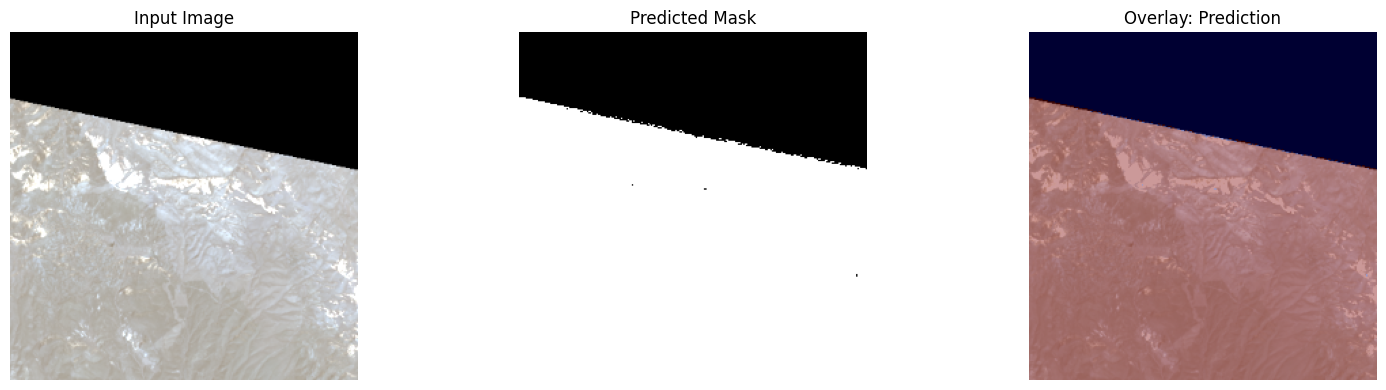

Size of the Pred mask is:  (256, 256, 1)


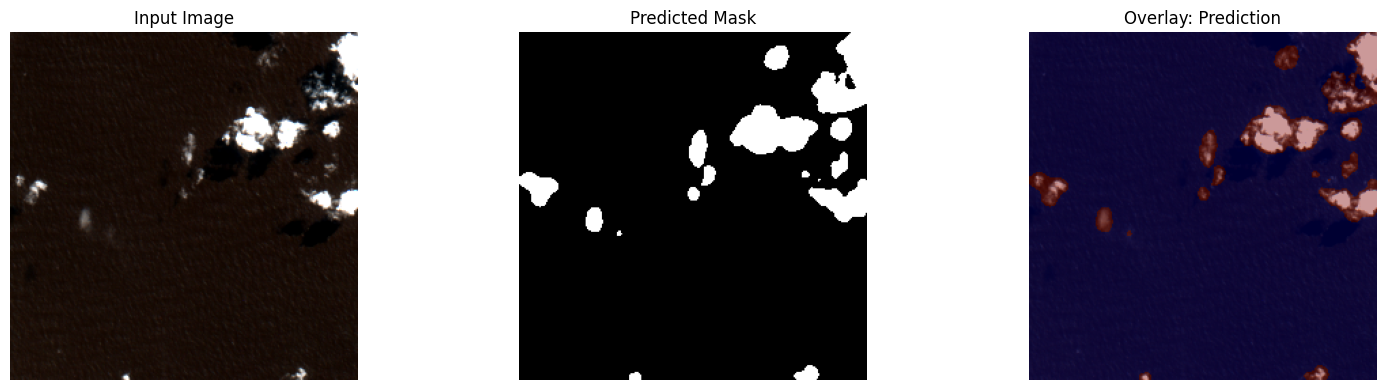

Size of the Pred mask is:  (256, 256, 1)


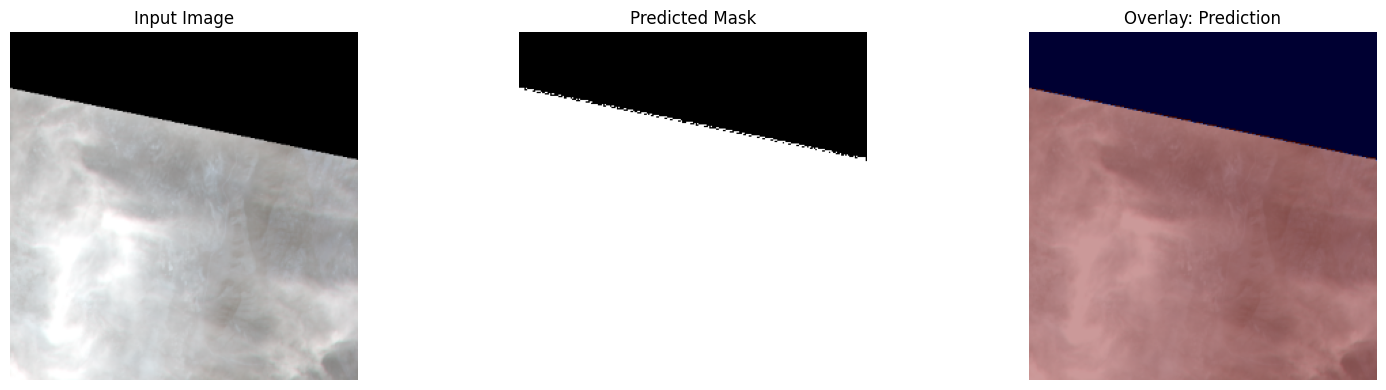

In [210]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

def normalize_img(img, lower_percent=2, upper_percent=98):
    out = np.zeros_like(img, dtype=np.float32)
    for i in range(3):  # Only RGB channels
        band = img[:, :, i]
        min_val = np.percentile(band, lower_percent)
        max_val = np.percentile(band, upper_percent)
        out[:, :, i] = np.clip((band - min_val) / (max_val - min_val + 1e-6), 0, 1)
    return out

def display_predictions_inference(dataset, model, num=3, overlay=True):
    for batch in dataset.take(1):  # one batch only
        x, batch_ids = batch  # Unpack images, masks, and IDs
        preds = model.predict(x) 
        for i in range(min(num, x.shape[0])):
            input_img = x[i].numpy()
            pred_mask = preds[i]
            print("Size of the Pred mask is: ",pred_mask.shape)
            # Normalize input image for visualization
            rgb_img = input_img[:, :, :3]
            norm_rgb = normalize_img(rgb_img)

            # Convert predicted mask to binary
            bin_pred_mask = (pred_mask > 0.5).astype(np.uint8)

            plt.figure(figsize=(16, 4))

            plt.subplot(1, 3, 1)
            plt.imshow(norm_rgb)
            plt.title("Input Image")
            plt.axis("off")

            plt.subplot(1, 3, 2)
            plt.imshow(bin_pred_mask.squeeze(), cmap='gray')
            plt.title("Predicted Mask")
            plt.axis("off")

            plt.subplot(1, 3, 3)
            plt.imshow(norm_rgb)
            plt.imshow(bin_pred_mask.squeeze(), alpha=0.4, cmap='jet')
            plt.title("Overlay: Prediction")
            plt.axis("off")

            plt.tight_layout()
            plt.show()
display_predictions_inference(test_ds_id, model, num=3, overlay=True)

## Visualization of Model Predictions

This cell provides visualization utilities to inspect model predictions on validation data.

- **normalize_img(img, lower_percent=2, upper_percent=98)**:  
  Normalizes RGB channels of the input image for better visualization by stretching pixel values between specified percentiles.

- **display_predictions(dataset, model, num=3, overlay=True)**:  
  - Runs inference on a batch from the provided dataset.
  - For each sample, displays:
    1. The normalized input image (RGB).
    2. The ground truth mask.
    3. The predicted mask (thresholded at 0.5).
    4. An overlay of the predicted mask on the input image for qualitative assessment.

This visualization helps to qualitatively evaluate the segmentation performance and identify strengths or weaknesses in the model's predictions.

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 436ms/step
Size of the true mask is:  (256, 256, 1)
Size of the Pred mask is:  (256, 256, 1)


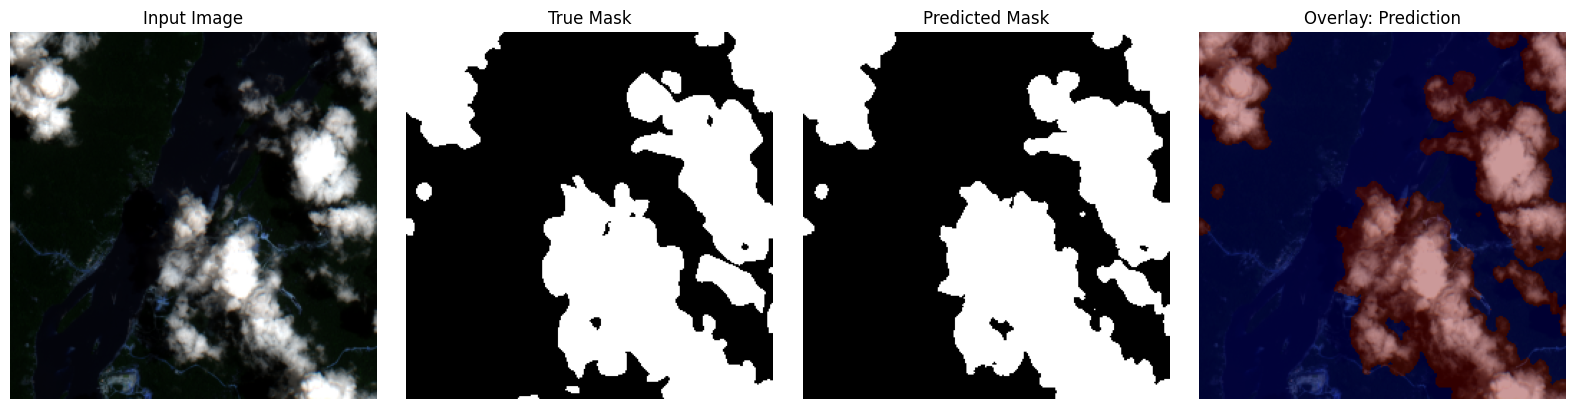

Size of the true mask is:  (256, 256, 1)
Size of the Pred mask is:  (256, 256, 1)


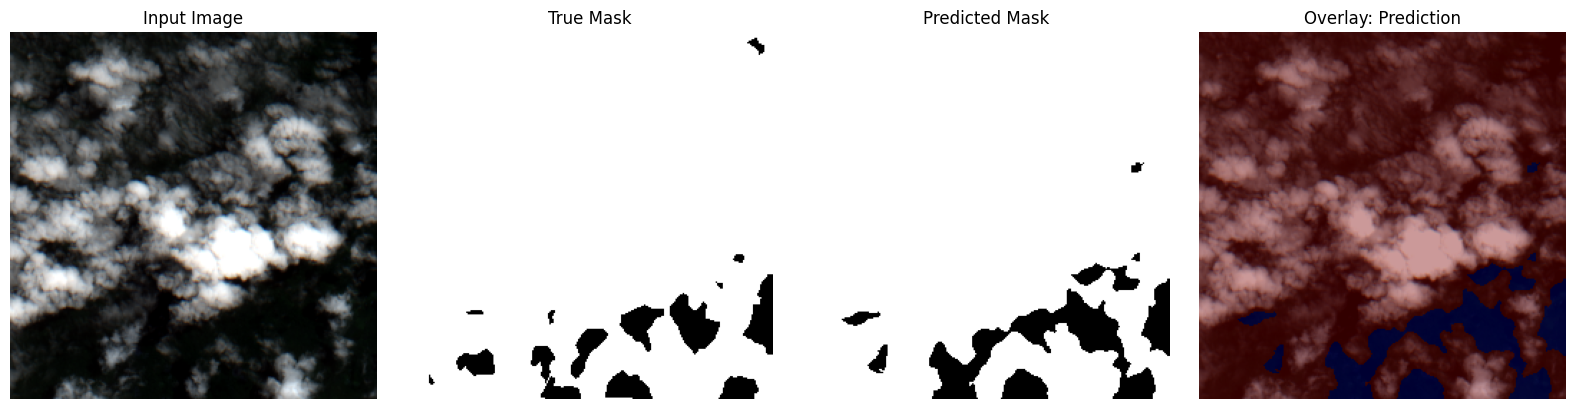

Size of the true mask is:  (256, 256, 1)
Size of the Pred mask is:  (256, 256, 1)


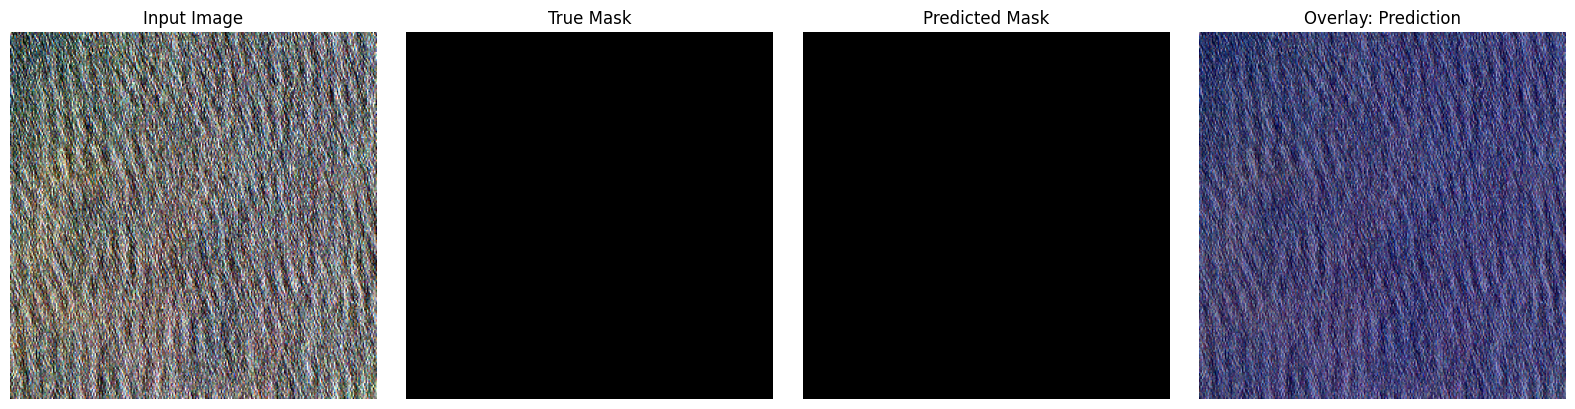

In [212]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

def normalize_img(img, lower_percent=2, upper_percent=98):
    out = np.zeros_like(img, dtype=np.float32)
    for i in range(3):  # Only RGB channels
        band = img[:, :, i]
        min_val = np.percentile(band, lower_percent)
        max_val = np.percentile(band, upper_percent)
        out[:, :, i] = np.clip((band - min_val) / (max_val - min_val + 1e-6), 0, 1)
    return out

def display_predictions(dataset, model, num=3, overlay=True):
    for image_batch, mask_batch in dataset.take(1):  # one batch only
        preds = model.predict(image_batch)

        for i in range(min(num, image_batch.shape[0])):
            input_img = image_batch[i].numpy()
            true_mask = mask_batch[i].numpy()
            print("Size of the true mask is: ",true_mask.shape)
            pred_mask = preds[i]
            print("Size of the Pred mask is: ",pred_mask.shape)
            # Normalize input image for visualization
            rgb_img = input_img[:, :, :3]
            norm_rgb = normalize_img(rgb_img)

            # Convert predicted mask to binary
            bin_pred_mask = (pred_mask > 0.5).astype(np.uint8)

            plt.figure(figsize=(16, 4))

            plt.subplot(1, 4, 1)
            plt.imshow(norm_rgb)
            plt.title("Input Image")
            plt.axis("off")

            plt.subplot(1, 4, 2)
            plt.imshow(true_mask.squeeze(), cmap='gray')
            plt.title("True Mask")
            plt.axis("off")

            plt.subplot(1, 4, 3)
            plt.imshow(bin_pred_mask.squeeze(), cmap='gray')
            plt.title("Predicted Mask")
            plt.axis("off")

            plt.subplot(1, 4, 4)
            plt.imshow(norm_rgb)
            plt.imshow(bin_pred_mask.squeeze(), alpha=0.4, cmap='jet')
            plt.title("Overlay: Prediction")
            plt.axis("off")

            plt.tight_layout()
            plt.show()
display_predictions(val_ds, model, num=3, overlay=True)